# Five Baseflow Separation Methods:
#### (1) Numerical method
#### (2) SC mass balance method
#### (3) Digital filter method
#### (4) UKIH method
#### (5) PH graphical method

### Pip install functions

In [1]:
# !pip install modvis
# !pip install baseflow==0.0.9
# !pip install hydroeval
# !pip install dataretrieval

In [2]:
import h5py
import baseflow
from modvis import ATSutils
from modvis import utils
from modvis import general_plots as gp
import pandas as pd
import numpy as np
from dataretrieval import nwis
from dataretrieval import wqp
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D 
from matplotlib.patches import Patch
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
from scipy import stats


from scipy.optimize import curve_fit
from scipy.stats import linregress
import h5py
import sys, os
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

from tqdm import tqdm
from pathlib import Path
from baseflow.methods import *
from baseflow.comparision import strict_baseflow, KGE
from baseflow.utils import clean_streamflow, exist_ice, geo2imagexy, format_method
from baseflow.param_estimate import recession_coefficient, param_calibrate, maxmium_BFI

from hydroeval import evaluator, nse, kge

surf_area = 53159325.46184719 # in square meters
area = 20.3 #square miles
fontsize = 14

#### Make a folder

In [3]:
os.makedirs("figures", exist_ok=True)

# (1) Numerical model results and baseflow calculations: 

## Reading 'base_calibrated-wb-2014_2022-GW.csv'

In [4]:
df = pd.read_csv(os.path.join('base_calibrated-wb-2014_2022-GW.csv'), comment='#')

df['datetime'] = pd.to_datetime(df['datetime'])
df = df[(df['datetime'] >= '2015-10-01') & (df['datetime'] <= '2022-09-30')]


## Convert data to cms and plot it

In [5]:
df['watershed boundary discharge [m3 s^-1]'] = df['watershed boundary discharge [mol d^-1]']/55500/24/60/60

df['exfiltration [m3 s^-1]'] = df['exfiltration [mol d^-1]']/55500/24/60/60

df['snowmelt [m3 s^-1]'] = df['snowmelt [m d^-1]']/55500/24/60/60

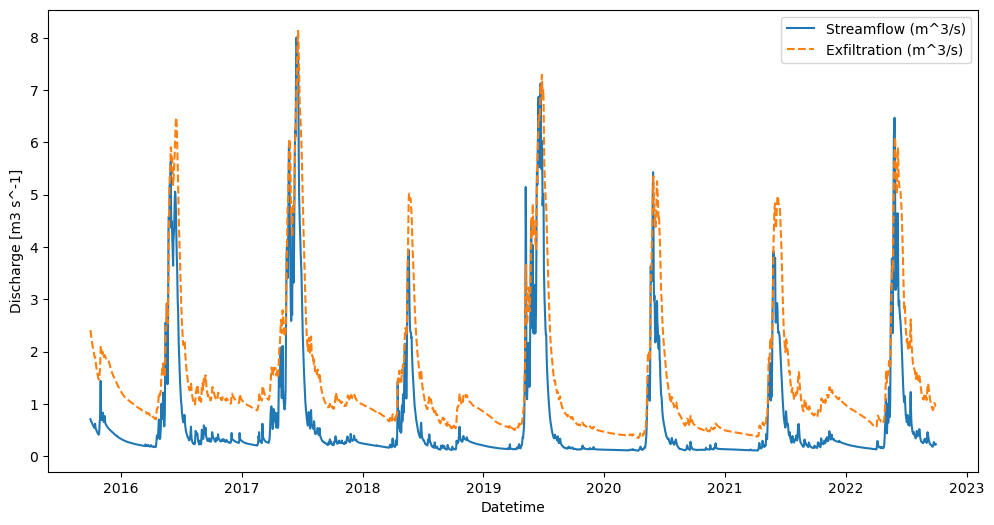

In [6]:
plt.figure(figsize=(12, 6))

plt.plot(df['datetime'], df['watershed boundary discharge [m3 s^-1]'], label='Streamflow (m^3/s)')
plt.plot(df['datetime'], df['exfiltration [m3 s^-1]'], label='Exfiltration (m^3/s)', linestyle='--')

# Adding labels and title
plt.xlabel('Datetime')
plt.ylabel('Discharge [m3 s^-1]')

# Adding legend
plt.legend()
plt.show()

#### The total exfiltration in the figure above is higher than the total discharge due to reexfiltration. The total exfiltration now equals the sum of baseflow and reexfiltration.

##### First, demonstrate the presence of reinfiltration leading to reexfiltration by plotting both exfiltration and infiltration. If infiltration during the dry season is not zero, this indicates reinfiltration. We then assume that the amount of reinfiltration is equal to the exfiltration. Therefore, once reinfiltration is confirmed, it is assumed to be equal to the reexfiltration. 

## Proving the existence of re-infiltration and calculating the dry period baseflow:
##### Assume that the infiltration is zero when rainfall and snowmelt are zero. filter the rows that apply these conditions and assume that the baseflow is equal to water content change - transpiration. Plot the baseflow of the dry period

In [7]:
df['infiltration [m d^-1]'] =  df['infiltration [mol d^-1]']/55500./surf_area
df['net runoff [m d^-1]'] = df['net runoff [mol d^-1]']/55500./surf_area
df['subsurface water content [m]'] = df['subsurface water content [mol]'] / 55500 / surf_area
df['subsurface water content change [m d^-1]'] = df['subsurface water content [m]'].diff()

## If it is a dry period (when precipitation and snowmelt are zero), the baseflow equals the negative of the subsurface water content change
## This equation calculates the baseflow during dry periods only, leaving the values blank for all other conditions

df['GW_discharge [m d^-1]'] =  -df['subsurface water content change [m d^-1]'] - df['transpiration [m d^-1]']
df['GW_discharge_new_dryperiod [m d^-1]'] = df.apply(
    lambda row: row['GW_discharge [m d^-1]'] if row['snowmelt [m d^-1]'] == 0 and row['rain precipitation [m d^-1]'] == 0 
    else np.nan,
    axis=1)

df['reinfiltration_new_dryperiod [m d^-1]'] = df.apply(
    lambda row: row['exfiltration [m d^-1]'] - row['GW_discharge_new_dryperiod [m d^-1]'] if row['snowmelt [m d^-1]'] == 0 and row['rain precipitation [m d^-1]'] == 0 
    else np.nan,
    axis=1)

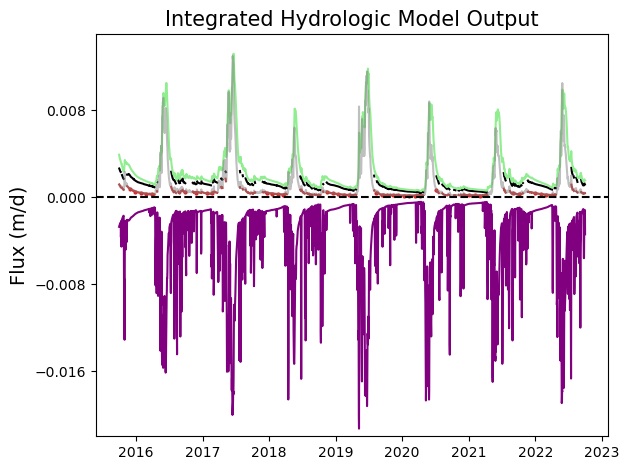

In [8]:
fig, ax1 = plt.subplots()


ax1.plot(df['datetime'], df['GW_discharge_new_dryperiod [m d^-1]'], label='Baseflow (Dry Period)', color='tab:red', marker="o", markevery=30, markersize=2)
ax1.plot(df['datetime'], df['reinfiltration_new_dryperiod [m d^-1]'], label='Re-exfiltration (Dry Period)', color='black')
ax1.plot(df['datetime'], df['exfiltration [m d^-1]'], label='Total Exfiltration', color='lightgreen')
ax1.plot(df['datetime'], df['infiltration [m d^-1]'], label='Total Infiltration', color='purple')
ax1.plot(df['datetime'], df['net runoff [m d^-1]'], label='Streamflow', color='gray', alpha=0.5)

ax1.axhline(y=0, color='black', linestyle='--')


ax1.set_ylabel('Flux (m/d)', fontsize = fontsize)
ax1.set_ylim(-0.022, 0.015)
ax1.set_yticks(np.arange(-0.02, 0.02, 0.01))
ax1.yaxis.set_major_locator(MaxNLocator(nbins=6))

# Legend
# ax1.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.title('Integrated Hydrologic Model Output', fontsize=15)
plt.tight_layout()
# Save and show plot
plt.savefig('figures/reinfiltration_proof', dpi=500, bbox_inches='tight')
plt.show()




In [9]:
# --- create a separate dataframe for the dry-period comparison ---
dry_df = df[['datetime',
             'GW_discharge_new_dryperiod [m d^-1]',
             'net runoff [m d^-1]']].copy()

dry_df = dry_df.rename(columns={
    'GW_discharge_new_dryperiod [m d^-1]': 'baseflow_dry',
    'net runoff [m d^-1]': 'streamflow_dry'
})

# keep only rows where dry-period baseflow exists
dry_df = dry_df.dropna(subset=['baseflow_dry', 'streamflow_dry'])

x = dry_df['streamflow_dry']
y = dry_df['baseflow_dry']


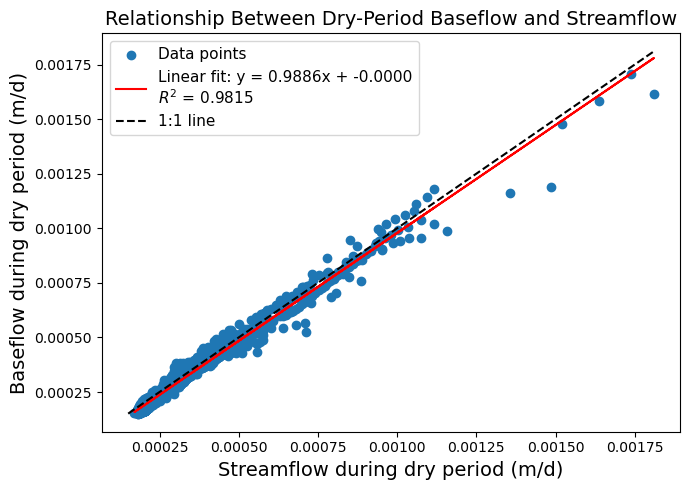

In [10]:
plt.figure(figsize=(7,5))
plt.scatter(x, y, label='Data points')

# linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

plt.plot(x, slope * x + intercept,
         color='red',
         label=f'Linear fit: y = {slope:.4f}x + {intercept:.4f}\n$R^2$ = {r_value**2:.4f}')

# optional 1:1 line
vmin = min(x.min(), y.min())
vmax = max(x.max(), y.max())
plt.plot([vmin, vmax], [vmin, vmax],
         color='black', linestyle='--', label='1:1 line')

plt.xlabel('Streamflow during dry period (m/d)', fontsize=fontsize)
plt.ylabel('Baseflow during dry period (m/d)', fontsize=fontsize)
plt.title('Relationship Between Dry-Period Baseflow and Streamflow', fontsize=fontsize)

plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('figures/Relationship_Between_Baseflow_and_Streamflow_During_Dry_Period.png', dpi=500)
plt.show()

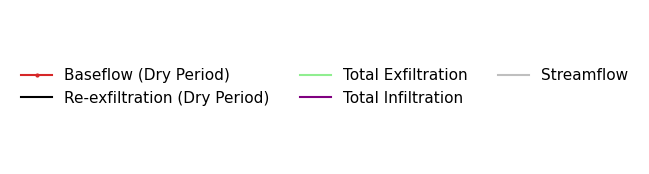

In [11]:
handles, labels = ax1.get_legend_handles_labels()

# create a new figure only for the legend
fig_leg = plt.figure(figsize=(8,2))

fig_leg.legend(handles, labels,
               loc='center',
               ncol=3,
               fontsize=11,
               frameon=False)

plt.axis('off')

plt.savefig('figures/reinfiltration_proof_legend.png',
            dpi=500,
            bbox_inches='tight')

plt.show()


#### Find the relationship between reinfiltration and streamflow. Use this relationship to find the continuous reinfiltration and then plot baseflow = exfiltration - reinfiltration

#### Linear relationship

In [12]:
filtered_df = df.dropna(subset=['reinfiltration_new_dryperiod [m d^-1]'])

x = filtered_df['exfiltration [m d^-1]']
y = filtered_df['reinfiltration_new_dryperiod [m d^-1]']


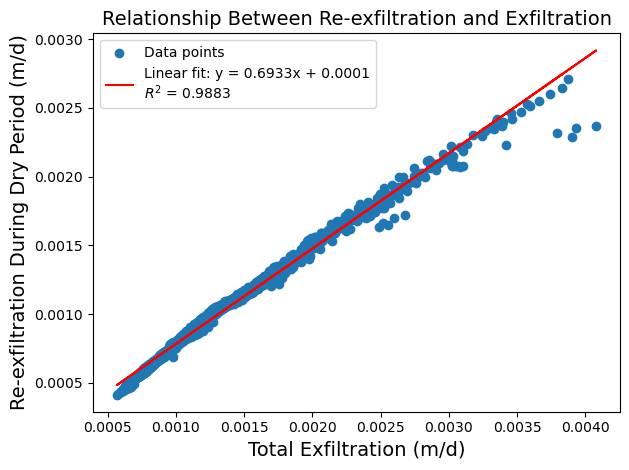

In [13]:

plt.figure()
plt.scatter(x, y, label='Data points')
plt.xlabel('Total Exfiltration (m/d)', fontsize = fontsize)
plt.ylabel('Re-exfiltration During Dry Period (m/d)', fontsize = fontsize)

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

plt.plot(x, slope * x + intercept, color='red', label=f'Linear fit: y = {slope:.4f}x + {intercept:.4f}\n$R^2$ = {r_value**2:.4f}')



plt.legend()



plt.title('Relationship Between Re-exfiltration and Exfiltration', fontsize = fontsize)

plt.tight_layout()

plt.savefig('figures/Relationship_Between_Re-exfiltration_and_Exfiltration',dpi = 500)
plt.show()


In [14]:
df['daily_reinfiltration_lin [m d^-1]'] = 0.6933 * df['exfiltration [m d^-1]'] + 0.0001
df['baseflow_lin [m d^-1]'] = df['exfiltration [m d^-1]'] - df['daily_reinfiltration_lin [m d^-1]']


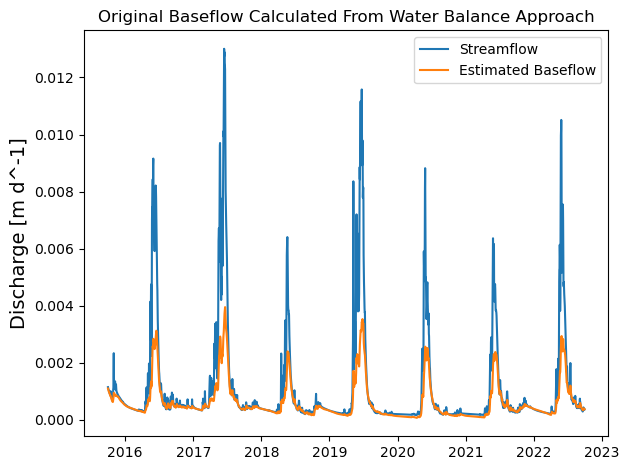

In [15]:
plt.figure()
plt.plot(df['datetime'], df['net runoff [m d^-1]'], label='Streamflow')


plt.plot(df['datetime'], df['baseflow_lin [m d^-1]'], label='Estimated Baseflow')

plt.ylabel('Discharge [m d^-1]', fontsize = fontsize)
plt.title('Original Baseflow Calculated From Water Balance Approach')
plt.legend()


plt.tight_layout()
plt.show()


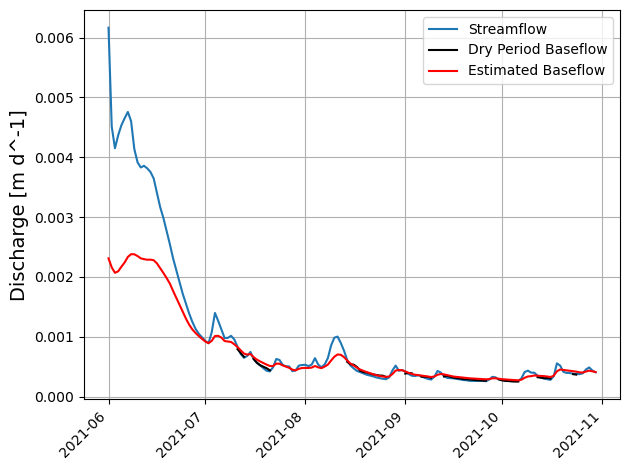

In [16]:

start_date = '2021-06-01'
end_date = '2021-10-30'
filtered_df = df[(df['datetime'] >= start_date) & (df['datetime'] <= end_date)]

plt.figure()
plt.plot(filtered_df['datetime'], filtered_df['net runoff [m d^-1]'], label='Streamflow')
plt.plot(filtered_df['datetime'], filtered_df['GW_discharge_new_dryperiod [m d^-1]'], label='Dry Period Baseflow', color = 'black')


plt.plot(filtered_df['datetime'], filtered_df['baseflow_lin [m d^-1]'], label='Estimated Baseflow', color='red')

plt.ylabel('Discharge [m d^-1]', fontsize = fontsize)

plt.legend()
# plt.ylim(0, 0.003)
plt.grid(True)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gcf().autofmt_xdate(rotation=45, ha='right')
plt.tight_layout()
plt.show()


#### The figures above show that the estimated baseflow might exceed the streamflow in low flow periods, thus, baseflow is removed for the days of sxceedance. These are the following steps:

#### Checking if there are days of baseflow greater than streamflow
#### Find the average exceedance
#### Find the exceedance days per each month of each year and the average exceedance

In [17]:
df['baseflow_greater_than_runoff'] = df['baseflow_lin [m d^-1]'] > df['net runoff [m d^-1]']
df['exceedance'] = df['baseflow_lin [m d^-1]'] - df['net runoff [m d^-1]']
df['percentage_exceedance'] = (df['exceedance'] / df['net runoff [m d^-1]']) * 100

exceedance_df = df[df['baseflow_greater_than_runoff']]

dates_with_condition = exceedance_df[['datetime', 'percentage_exceedance']]


In [18]:
# Calculating the exceedance days for each month:
overall_percentage_exceedance = exceedance_df['percentage_exceedance'].mean()
exceedance_df['year_month'] = exceedance_df['datetime'].dt.to_period('M')
grouped = exceedance_df.groupby('year_month').agg(
    days_of_exceedance=('percentage_exceedance', 'size'),
    average_exceedance=('percentage_exceedance', 'mean')
).reset_index()

C:\Users\jihad\AppData\Local\Temp\ipykernel_36352\4209625419.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exceedance_df['year_month'] = exceedance_df['datetime'].dt.to_period('M')


In [19]:
exceedance_df['month'] = exceedance_df['datetime'].dt.month

grouped_monthly = exceedance_df.groupby('month').agg(
    days_of_exceedance=('percentage_exceedance', 'size'),
    average_exceedance=('percentage_exceedance', 'mean'),
    min_exceedance=('percentage_exceedance', 'min'),
    max_exceedance=('percentage_exceedance', 'max'),
    stddev_exceedance=('percentage_exceedance', 'std')
).reset_index()
grouped_monthly

C:\Users\jihad\AppData\Local\Temp\ipykernel_36352\2264363536.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exceedance_df['month'] = exceedance_df['datetime'].dt.month


,month,days_of_exceedance,average_exceedance,min_exceedance,max_exceedance,stddev_exceedance
0,1,67,2.878652,0.034627,7.161801,2.600682
1,2,87,2.890047,0.026023,7.173408,2.006428
2,3,36,2.747454,0.228552,6.089564,1.800349
3,6,9,6.507989,0.266587,9.738908,2.767348
4,7,88,7.359262,0.236338,23.918955,5.625061
5,8,115,10.961142,0.001310,29.853322,6.494202
6,9,100,9.059206,0.156472,24.072435,6.435455
7,10,33,6.076839,0.214422,16.814227,4.579696
8,11,2,1.379324,0.756540,2.002109,0.880751
9,12,23,1.123214,0.012133,2.692765,0.945425


In [20]:
df['final_baseflow [m d^-1]'] = np.where(
    df['baseflow_greater_than_runoff'] & df['reinfiltration_new_dryperiod [m d^-1]'].notna(),
    df['GW_discharge_new_dryperiod [m d^-1]'],
    df['baseflow_lin [m d^-1]']
)

In [21]:
df['baseflow_greater_than_runoff_final'] = df['final_baseflow [m d^-1]'] > df['net runoff [m d^-1]']
dates_with_condition_final = df[df['baseflow_greater_than_runoff_final']]['datetime']


#### Setting the rows that still have baseflow greater than streamflow to be equal to the streamflow: 

In [22]:
# Replace in daily units (recommended to avoid rounding twice)
mask = df['baseflow_greater_than_runoff_final'].fillna(False)
df.loc[mask, 'final_baseflow [m d^-1]'] = df.loc[mask, 'net runoff [m d^-1]']

# Convert to m3/s
sec_per_day = 24 * 60 * 60
df['net runoff [m3 s^-1]']     = df['net runoff [m d^-1]'] * surf_area / sec_per_day
df['final_baseflow [m3 s^-1]'] = df['final_baseflow [m d^-1]'] * surf_area / sec_per_day
df['snowmelt [m3 s^-1]'] = df['snowmelt [m d^-1]']* surf_area / sec_per_day

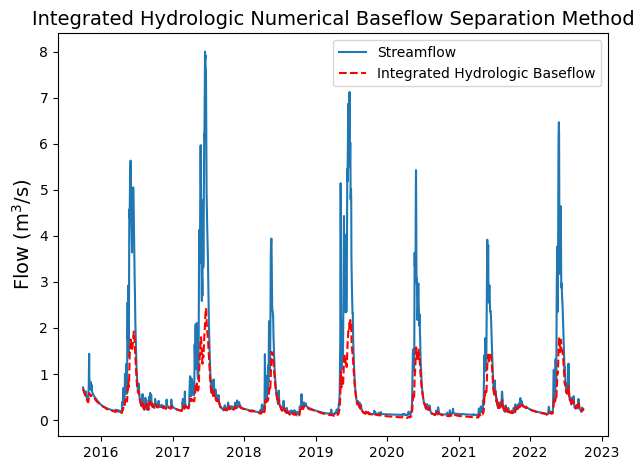

In [23]:
plt.figure()
plt.plot(df['datetime'], df['net runoff [m3 s^-1]'], label='Streamflow')
plt.plot(df['datetime'], df['final_baseflow [m3 s^-1]'], label='Integrated Hydrologic Baseflow', color='red', linestyle='--')

plt.ylabel(r'Flow (m$^3$/s)', fontsize = fontsize)
plt.legend()
plt.title('Integrated Hydrologic Numerical Baseflow Separation Method', fontsize = fontsize)
plt.tight_layout()
plt.savefig('figures/final_baseflow_numerical_method', dpi = 500)
plt.show()

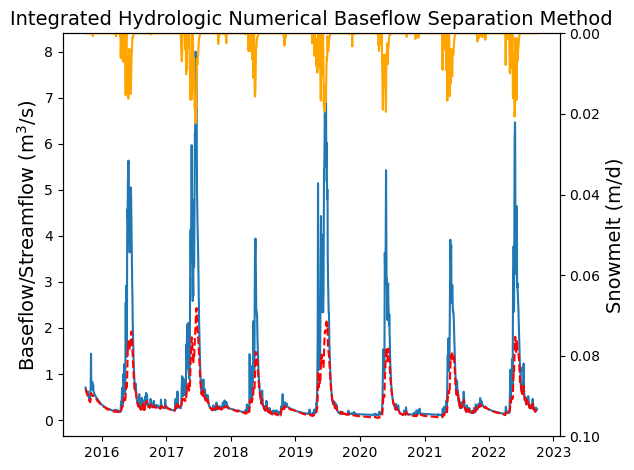

In [24]:
fig, ax1 = plt.subplots()

# Left axis: Streamflow & Baseflow
l1, = ax1.plot(df['datetime'], df['net runoff [m3 s^-1]'], label='Streamflow')
l2, = ax1.plot(
    df['datetime'],
    df['final_baseflow [m3 s^-1]'],
    label='Integrated Hydrologic Baseflow',
    color='red',
    linestyle='--'
)

ax1.set_ylabel(
    r'Baseflow/Streamflow (m$^3$/s)',
    fontsize=fontsize
)

# Right axis: Snowmelt
ax2 = ax1.twinx()
l3, = ax2.plot(df['datetime'], df['snowmelt [m d^-1]'], label='Snowmelt', color='orange')

ax2.set_ylabel(r'Snowmelt (m/d)', fontsize=fontsize)

# Force snowmelt scale (0–35, inverted)
ax2.set_ylim(0.1, 0)

plt.title(
    'Integrated Hydrologic Numerical Baseflow Separation Method',
    fontsize=fontsize
)

plt.tight_layout()
plt.savefig(
    'figures/final_baseflow_numerical_method_snowmelt',
    dpi=500,
    bbox_inches='tight'
)
plt.show()

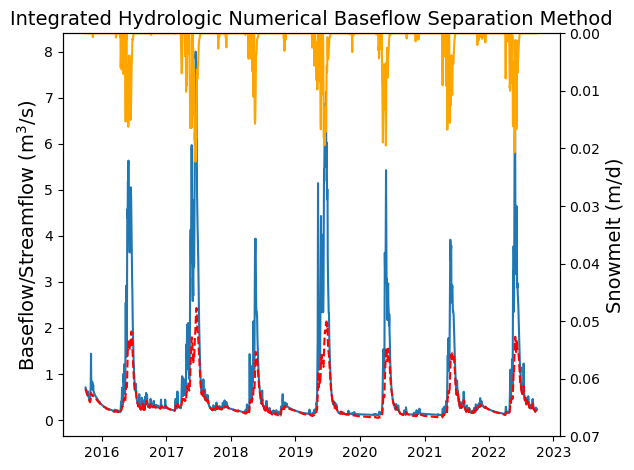

In [25]:
fig, ax1 = plt.subplots()

# Left axis: Streamflow & Baseflow
l1, = ax1.plot(df['datetime'], df['net runoff [m3 s^-1]'], label='Streamflow')
l2, = ax1.plot(
    df['datetime'], df['final_baseflow [m3 s^-1]'],
    label='Integrated Hydrologic Baseflow',
    color='red', linestyle='--'
)

ax1.set_ylabel(r'Baseflow/Streamflow (m$^3$/s)', fontsize=fontsize)

# Right axis: Snowmelt
ax2 = ax1.twinx()
l3, = ax2.plot(
    df['datetime'], df['snowmelt [m d^-1]'],
    label='Snowmelt',
    color='orange'
)

ax2.set_ylabel('Snowmelt (m/d)', fontsize=fontsize)

# Force snowmelt scale (inverted)
ax2.set_ylim(0.07, 0)

plt.title('Integrated Hydrologic Numerical Baseflow Separation Method', fontsize=fontsize)
plt.tight_layout()
plt.savefig('figures/final_baseflow_numerical_method_snowmelt', dpi=500, bbox_inches='tight')
plt.show()

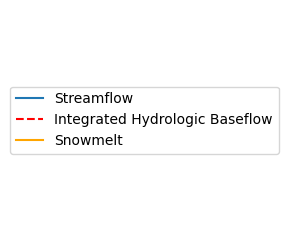

In [26]:
fig_leg = plt.figure(figsize=(3, 2.5))   # narrower & taller for vertical list
ax_leg = fig_leg.add_subplot(111)
ax_leg.axis('off')

ax_leg.legend(
    handles=[l1, l2, l3],
    labels=[
        'Streamflow',
        'Integrated Hydrologic Baseflow',
        'Snowmelt'
    ],
    loc='center',
    ncol=1,          
    frameon=True
)

fig_leg.tight_layout()
fig_leg.savefig(
    'figures/final_baseflow_numerical_method_snowmelt_legend_vertical',
    dpi=500,
    bbox_inches='tight'
)
plt.show()


In [27]:
df['datetime'] = pd.to_datetime(df['datetime'])

def yearly_peak(series, year):
    s = df.loc[df['datetime'].dt.year == year, series].dropna()
    if s.empty:
        return None, None
    peak_val = s.max()
    peak_day = df.loc[s.idxmax(), 'datetime']
    return peak_val, peak_day

def yearly_snowmelt_volume(year):
    """
    Snowmelt is in m/day.
    Summing over the year gives total melted depth in meters.
    """
    s = df.loc[df['datetime'].dt.year == year, 'snowmelt [m d^-1]'].dropna()
    return s.sum()

for y in [2018, 2019]:
    sm_val, sm_day = yearly_peak('snowmelt [m d^-1]', y)
    bf_val, bf_day = yearly_peak('final_baseflow [m3 s^-1]', y)
    sm_vol = yearly_snowmelt_volume(y)

    print(f"\nYear {y}")
    print(f"  Snowmelt peak: {sm_val} m/d on {sm_day.date() if sm_day is not None else None}")
    print(f"  Baseflow peak: {bf_val} m3/s on {bf_day.date() if bf_day is not None else None}")
    print(f"  Total snowmelt volume: {sm_vol} m")


Year 2018
  Snowmelt peak: 0.01571184645872 m/d on 2018-05-17
  Baseflow peak: 1.4777645404947484 m3/s on 2018-05-21
  Total snowmelt volume: 0.23444456638376868 m

Year 2019
  Snowmelt peak: 0.0194168570499 m/d on 2019-06-16
  Baseflow peak: 2.1739034548296488 m3/s on 2019-06-27
  Total snowmelt volume: 0.5549563093202312 m


#### Plotting the baseflow for three different years separately: 2016-2017, 2017-2018, and 2021. Change the startdate and the enddate

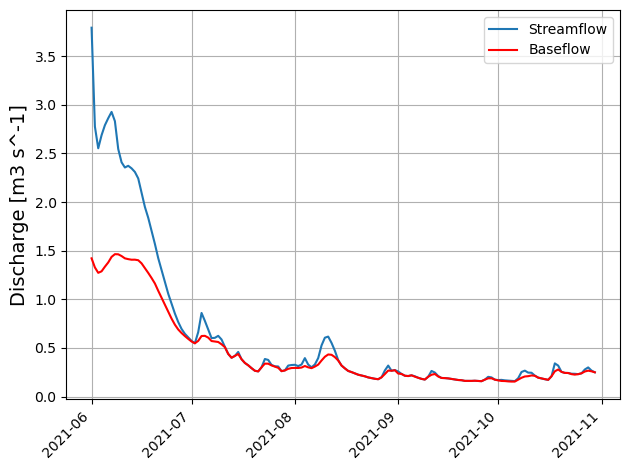

In [28]:
startdate = '2021-06-01'
enddate = '2021-10-30'
filtereddf = df[(df['datetime'] >= startdate) & (df['datetime'] <= enddate)]

plt.figure()
plt.plot(filtereddf['datetime'], filtereddf['net runoff [m3 s^-1]'], label='Streamflow')
plt.plot(filtereddf['datetime'], filtereddf['final_baseflow [m3 s^-1]'], label='Baseflow', color='red')


plt.ylabel('Discharge [m3 s^-1]', fontsize = fontsize)

plt.legend()

plt.grid(True)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gcf().autofmt_xdate(rotation=45, ha='right')
plt.tight_layout()
plt.show()


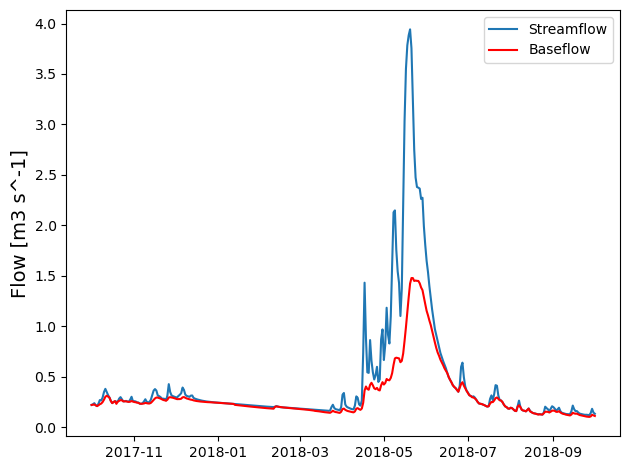

In [29]:
startdate = '2017-10-01'
enddate = '2018-10-01'
filtereddf = df[(df['datetime'] >= startdate) & (df['datetime'] <= enddate)]

plt.figure()
plt.plot(filtereddf['datetime'], filtereddf['net runoff [m3 s^-1]'], label='Streamflow')
plt.plot(filtereddf['datetime'], filtereddf['final_baseflow [m3 s^-1]'], label='Baseflow', color='red')


plt.ylabel('Flow [m3 s^-1]', fontsize = fontsize)

plt.legend()

plt.tight_layout()
plt.show()

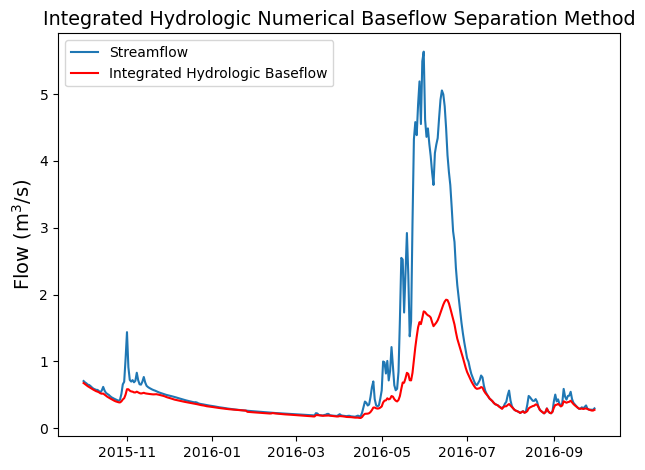

In [30]:
startdate = '2015-10-01'
enddate = '2016-09-30'
filtereddf = df[(df['datetime'] >= startdate) & (df['datetime'] <= enddate)]

plt.figure()
plt.plot(filtereddf['datetime'], filtereddf['net runoff [m3 s^-1]'], label='Streamflow')
plt.plot(filtereddf['datetime'], filtereddf['final_baseflow [m3 s^-1]'], label='Integrated Hydrologic Baseflow', color='red')


plt.ylabel(r'Flow (m$^3$/s)', fontsize = fontsize)

plt.legend()
plt.title('Integrated Hydrologic Numerical Baseflow Separation Method', fontsize = 13.84)
plt.tight_layout()
plt.show()

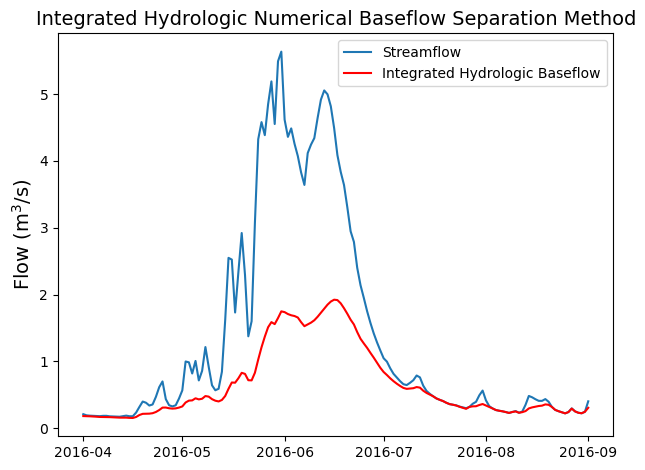

In [31]:
startdate = '2016-04-01'
enddate = '2016-09-01'
filtereddf = df[(df['datetime'] >= startdate) & (df['datetime'] <= enddate)]

plt.figure()
plt.plot(filtereddf['datetime'], filtereddf['net runoff [m3 s^-1]'], label='Streamflow')
plt.plot(filtereddf['datetime'], filtereddf['final_baseflow [m3 s^-1]'], label='Integrated Hydrologic Baseflow', color='red')


plt.ylabel(r'Flow (m$^3$/s)', fontsize = fontsize)

plt.legend()
plt.title('Integrated Hydrologic Numerical Baseflow Separation Method', fontsize = 13.95)
plt.tight_layout()
plt.show()

## Applying recession analysis to find the recession constant: 

## Plotting observed streamflow

#### Due to update in NWIS function, the line below doesnt work. So it is commented out, and a different way was applied to be able to use NWIS to retrieve the observed streamflow

In [32]:
# obs_df = utils.load_nwis(sites= "09111250", start = '2015-10-01', end = '2022-10-01')

In [33]:
def load_nwis_daily(site="09111250", start="2015-10-01", end="2022-10-01", parameter="00060"):
    # Fetch daily mean streamflow
    raw_data = nwis.get_record(sites=site, service="dv", start=start, end=end, parameterCd=parameter)

    # Ensure datetime index and drop timezone if present
    if 'datetime' in raw_data.columns:
        raw_data['datetime'] = pd.to_datetime(raw_data['datetime'])
        raw_data = raw_data.set_index('datetime')
    raw_data.index = pd.to_datetime(raw_data.index).tz_localize(None)

    # Choose the discharge column
    data_cols = [c for c in raw_data.columns if not c.endswith('_cd')]
    prefer = [c for c in data_cols if c.endswith('_00003') or c.endswith('_Mean') or c.endswith('_mean')]
    if prefer:
        col = prefer[0]
    else:
        cand = [c for c in data_cols if parameter in c] or data_cols
        col = cand[0]

    s = pd.to_numeric(raw_data[col], errors='coerce')
    s.name = "discharge_cfs"
    return s.to_frame()


obs_df = load_nwis_daily("09111250", "2015-10-01", "2022-10-01")


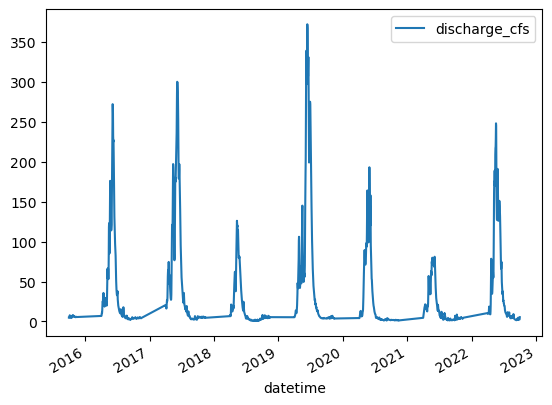

In [34]:
obs_df.plot()
plt.savefig('figures/obs_discharge.png')

In [35]:
obs_df["discharge_[m^3/d]"] = obs_df["discharge_cfs"] * 2446.575546
sim=df
sim = sim.set_index('datetime')

In [36]:
idx = sim.index.union(obs_df.index)

Q_sim  = sim.reindex(idx)['watershed boundary discharge [m^3/d]']
Q_obs  = obs_df.reindex(idx)['discharge_[m^3/d]']
rain   = sim.reindex(idx)['rain precipitation [m d^-1]'].fillna(0.0)
snow   = sim.reindex(idx)['snowmelt [m d^-1]'].fillna(0.0)

In [37]:
if len(idx) > 1:
    step_days = np.median(np.diff(mdates.date2num(idx)))
    barw = step_days * 0.9
else:
    barw = 0.8


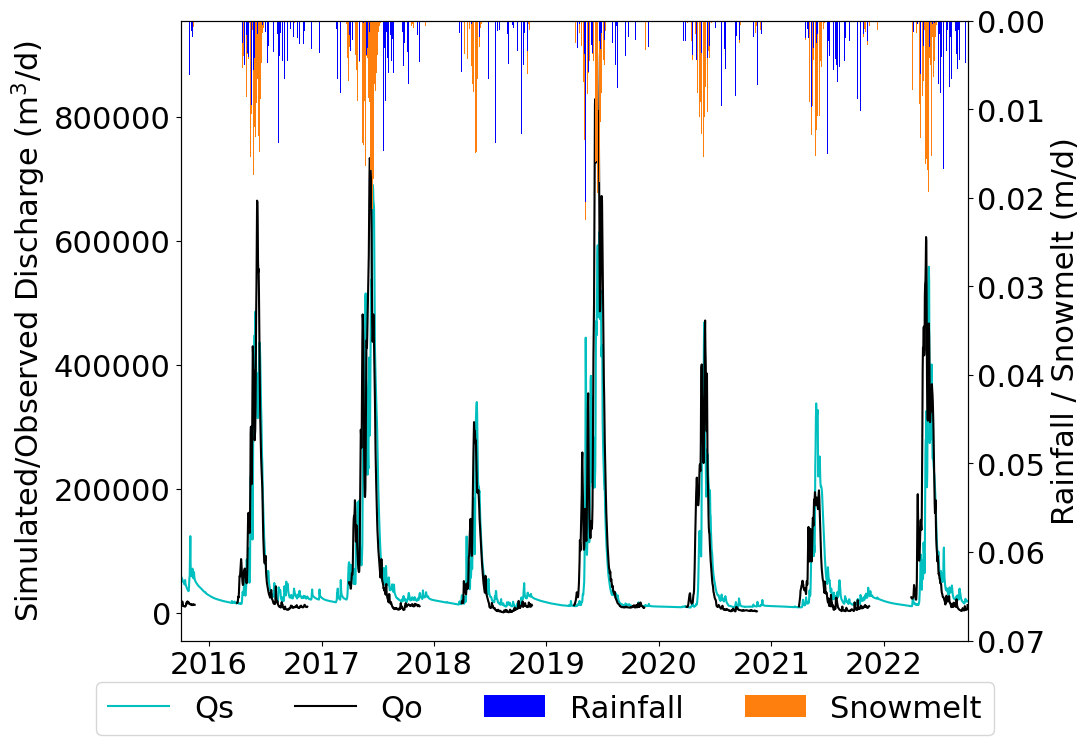

In [38]:

fig, ax1 = plt.subplots(figsize=(11, 7))

# Discharge lines
line1, = ax1.plot(idx, Q_sim, color='c', label=r'Qs', zorder=2)
line2, = ax1.plot(idx, Q_obs, color='k', label=r'Qo', zorder=99)
ax1.set_ylabel(r'Simulated/Observed Discharge (m$^3$/d)', fontsize=22)

# Rainfall & Snowmelt stacked bars on inverted twin axis
ax2 = ax1.twinx()
bar1 = ax2.bar(idx, rain, width=barw, color='b', label='Rainfall', linewidth=0)
bar2 = ax2.bar(idx, snow, width=barw, bottom=rain, color='#ff7f0e', label='Snowmelt', linewidth=0)

ax2.set_ylabel('Rainfall / Snowmelt (m/d)', fontsize=22)
ax2.invert_yaxis()
ax2.set_ylim(0.07, 0.00)  


ax1.tick_params(axis='both', labelsize=22)
ax2.tick_params(axis='y', labelsize=22)
ax1.set_xlim(idx.min(), idx.max())


handles = [line1, line2, bar1, bar2]
labels  = [h.get_label() for h in handles]
fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.08), fontsize = 22)

fig.patch.set_facecolor('white')
ax1.set_facecolor('white')
ax2.set_facecolor('white')

plt.tight_layout()
fig.savefig('figures/simu_obs_rain_snow.png', dpi=900, bbox_inches='tight', pad_inches=0.3)
plt.show()


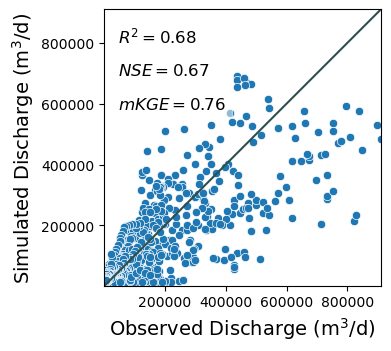

In [39]:

obs = obs_df['discharge_[m^3/d]']
simu = sim['watershed boundary discharge [m^3/d]']


aligned = (
    pd.concat([obs.rename('obs'), simu.rename('sim')], axis=1)
      .dropna()
)


aligned = aligned[aligned.index >= pd.to_datetime("2016-10-01")]

# One-to-one plot: observed first, simulated second
gp.one2one_plot(
    aligned['obs'],
    aligned['sim'],
    metrics=['R^2', 'NSE', 'mKGE'],
    show_density=False,
    start_date="2016-10-01"
)

# Labels and styling
fig = plt.gcf()
ax = plt.gca()
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.set_xlabel('Observed Discharge (m$^3$/d)', fontsize=fontsize)
ax.set_ylabel('Simulated Discharge (m$^3$/d)', fontsize=fontsize)

plt.tight_layout()

fig.savefig('figures/one2one_simu_obs.png', dpi=500)


## Calculating the average streamflow for the water year 2021 and that of the whole period to know if the streamflow of this year is below average or not: 


In [40]:
average_total_period = df['net runoff [m3 s^-1]'].mean()

specific_period_df = df.loc['2020-10-01':'2021-10-01']
average_specific_period = specific_period_df['net runoff [m3 s^-1]'].mean()

print(f'Average Streamflow of the entire period of study (2016-2022): {average_total_period:.2f} m3/s')
print(f'Average Streamflow of the water year 2021: {average_specific_period:.2f} m3/s')

Average Streamflow of the entire period of study (2016-2022): 0.68 m3/s
Average Streamflow of the water year 2021: 0.11 m3/s


# (2) SC mass balance method

### Retrieving the specific conductivity data for '09111250 coal creek wattershed'

##### Retrieving the SC from the USGS: Due to the update and maintenance in USGS, the nwis.get_qwdata used in the cell below doesnt work now. So we extracted SC measurements from USGS into the spreadsheet SC_try

In [41]:
# retrieving Specific Conductivity data for Coal Creek


# Inputs for site, variable, and date range
# site = '09111250'  # for Coal Creek
# pcode = '00095'    # for specific conductivity
# startdate = '1990-01-01'
# enddate = '2024-02-07'

# Retrieve data 
# SC = nwis.get_qwdata(sites=site,
#                  parameterCd=pcode,
#                  startDt=startdate,
#                  endDt=enddate)


In [42]:
SC_try = pd.read_csv(os.path.join('SC_try.csv'), comment='#')


SC = SC_try[['Activity_StartDate', 'Result_Measure']].copy()
SC.rename(columns={'Activity_StartDate': 'datetime'}, inplace=True)
SC.rename(columns={'Result_Measure': 'p00095'}, inplace=True)


SC['datetime'] = pd.to_datetime(SC['datetime'])
SC = SC.sort_values(by='datetime').set_index('datetime')


### Merging the specific conductivity measurements to the dataframe of the daily observed streamflow

In [43]:
# Ensure df has datetime index
if 'datetime' in df.columns:
    df = df.copy()
    df['datetime'] = pd.to_datetime(df['datetime'])
    df.set_index('datetime', inplace=True)

# Ensure SC has datetime index
if 'datetime' in SC.columns:
    SC = SC.copy()
    SC['datetime'] = pd.to_datetime(SC['datetime'])
    SC.set_index('datetime', inplace=True)

# Create merged_df (simulated discharge + SC)
# Keep all simulated timesteps; SC is sparse so will join as NaN where missing
merged_df = df.join(SC[['p00095']], how='left')

In [44]:
# Ensure obs_df has datetime index
if 'datetime' in obs_df.columns:
    obs_df = obs_df.copy()
    obs_df['datetime'] = pd.to_datetime(obs_df['datetime'])
    obs_df.set_index('datetime', inplace=True)

# Convert observed discharge from m3/day to m3/s
obs_df = obs_df.copy()
obs_df['observed discharge [m3 s^-1]'] = obs_df['discharge_[m^3/d]'] / 86400.0

# Build obs_like_df with SAME discharge naming used in your workflow
obs_like_df = pd.DataFrame(index=obs_df.index)
obs_like_df['watershed boundary discharge [m3 s^-1]'] = obs_df['observed discharge [m3 s^-1]']

# Join observed discharge with SC
obs_merged_df = obs_like_df.join(SC[['p00095']], how='left')

# Keep same two-column dataframe for observed fit
obs_new_dataframe = obs_merged_df[['watershed boundary discharge [m3 s^-1]', 'p00095']].copy()
obs_new_dataframe['p00095'].replace(-999999, np.nan, inplace=True)

C:\Users\jihad\AppData\Local\Temp\ipykernel_36352\2465240924.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  obs_new_dataframe['p00095'].replace(-999999, np.nan, inplace=True)


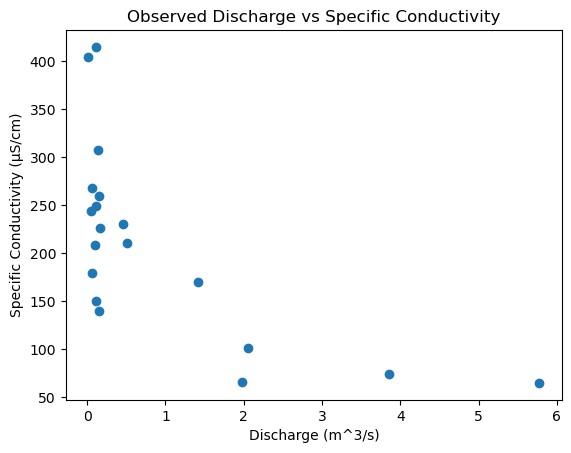

In [45]:
plt.scatter(obs_new_dataframe['watershed boundary discharge [m3 s^-1]'], obs_new_dataframe['p00095'])
plt.xlabel('Discharge (m^3/s)')
plt.ylabel('Specific Conductivity (µS/cm)')
plt.title('Observed Discharge vs Specific Conductivity')
plt.grid(False)
plt.show()


Number of valid SC observations (obs Q): 19


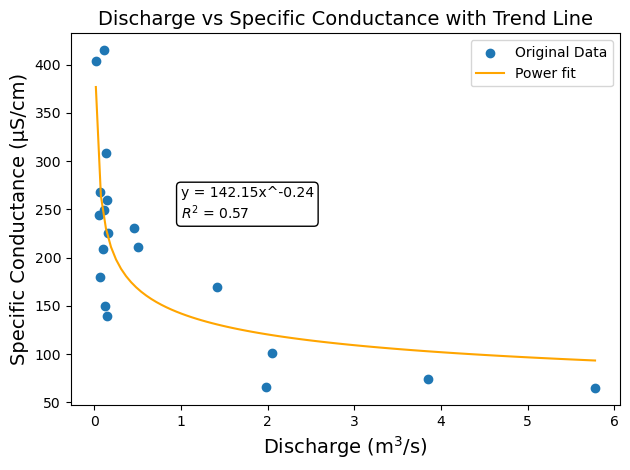

Observed Q power-fit params: [142.14723325  -0.23926507]
Observed Q R^2: 0.5676478838625056


In [46]:

sc_count_obs = obs_new_dataframe['p00095'].count()
print(f"Number of valid SC observations (obs Q): {sc_count_obs}")

# Clean data for curve fit
cleaned_obs = obs_new_dataframe.dropna(subset=['watershed boundary discharge [m3 s^-1]', 'p00095']).copy()

x_cleaned_obs = cleaned_obs['watershed boundary discharge [m3 s^-1]'].values
y_cleaned_obs = cleaned_obs['p00095'].values

def power_func(x, a, b):
    return a * np.power(x, b)

# Remove non-positive flows (power law can break for x <= 0)
mask_pos = x_cleaned_obs > 0
x_cleaned_obs = x_cleaned_obs[mask_pos]
y_cleaned_obs = y_cleaned_obs[mask_pos]
cleaned_obs = cleaned_obs.iloc[np.where(mask_pos)[0]]

# Fit power function using observed discharge
popt_obs, pcov_obs = curve_fit(power_func, x_cleaned_obs, y_cleaned_obs)

# Trend line + R2
x_fit_obs = np.linspace(x_cleaned_obs.min(), x_cleaned_obs.max(), 100)
y_fit_obs = power_func(x_fit_obs, *popt_obs)

residuals_obs = y_cleaned_obs - power_func(x_cleaned_obs, *popt_obs)
ss_res_obs = np.sum(residuals_obs**2)
ss_tot_obs = np.sum((y_cleaned_obs - np.mean(y_cleaned_obs))**2)
r_squared_obs = 1 - (ss_res_obs / ss_tot_obs)

plt.scatter(x_cleaned_obs, y_cleaned_obs, label='Original Data')
plt.plot(x_fit_obs, y_fit_obs, color='orange', label='Power fit')

plt.xlabel(r'Discharge (m$^3$/s)', fontsize=fontsize)
plt.ylabel('Specific Conductance (µS/cm)', fontsize=fontsize)
plt.title('Discharge vs Specific Conductance with Trend Line', fontsize=fontsize)
plt.grid(False)

equation_text_obs = f'y = {popt_obs[0]:.2f}x^{popt_obs[1]:.2f}\n$R^2$ = {r_squared_obs:.2f}'
plt.annotate(equation_text_obs, xy=(0.2, 0.50), xycoords='axes fraction',
             bbox=dict(boxstyle="round", fc="w"))

plt.legend()
plt.tight_layout()
plt.savefig('figures/obs_discharge_SC_relationship.png', dpi=500)
plt.show()

print("Observed Q power-fit params:", popt_obs)
print("Observed Q R^2:", r_squared_obs)

In [47]:
# Replace SC missing flag in simulated merged_df as well (for counting / any uses)
merged_df['p00095'].replace(-999999, np.nan, inplace=True)

# Estimate continuous SC on the simulated timeline using the OBS-fit parameters
merged_df['interpolated_SC_power_obsfit'] = power_func(
    merged_df['watershed boundary discharge [m3 s^-1]'].values, *popt_obs
)

C:\Users\jihad\AppData\Local\Temp\ipykernel_36352\1430526318.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_df['p00095'].replace(-999999, np.nan, inplace=True)


In [48]:
snowmelt_period_obs = obs_new_dataframe[(obs_new_dataframe.index.month == 5) | (obs_new_dataframe.index.month == 6)]
ro_end_member_obs = snowmelt_period_obs['p00095'].mean()

bf_end_member_sim = merged_df['interpolated_SC_power_obsfit'].quantile(0.99)

print("Runoff end member (SCro, from obs SC May+Jun):", ro_end_member_obs)
print("Baseflow end member (SCbf, 99th pct of sim-SC):", bf_end_member_sim)

Runoff end member (SCro, from obs SC May+Jun): 76.5
Baseflow end member (SCbf, 99th pct of sim-SC): 239.6332007845834


In [49]:
sc_obs_all = SC['p00095'].replace(-999999, np.nan).dropna()
sc_obs_plot = sc_obs_all.loc[sc_obs_all.index <= '2022-10-01']

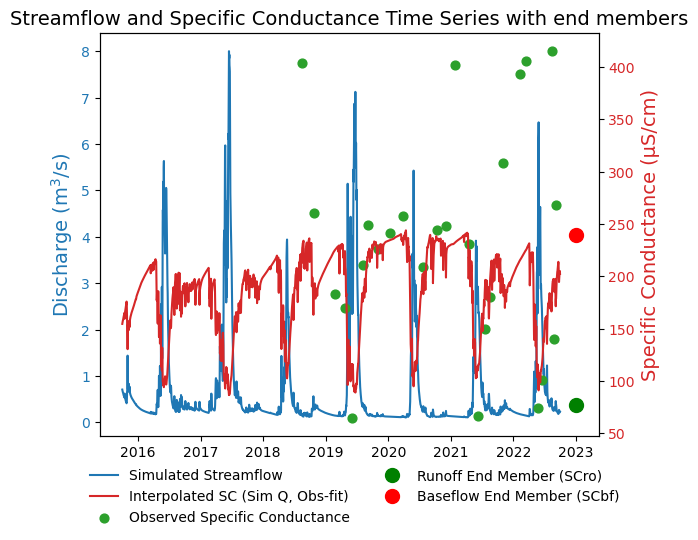

In [50]:
fig, ax1 = plt.subplots()

ax1.set_ylabel(r'Discharge (m$^3$/s)', color='tab:blue', fontsize=fontsize)
ax1.plot(merged_df.index, merged_df['watershed boundary discharge [m3 s^-1]'],
         label='Simulated Streamflow', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Specific Conductance (µS/cm)', color='tab:red', fontsize=fontsize)

ax2.plot(merged_df.index, merged_df['interpolated_SC_power_obsfit'],
         linestyle='-', label='Interpolated SC (Sim Q, Obs-fit)', color='tab:red')

# ax2.scatter(cleaned_obs.index, cleaned_obs['p00095'],
#             color='tab:green', label='Observed Specific Conductance', marker='o', s=40)

ax2.scatter(sc_obs_plot.index, sc_obs_plot.values,
            color='tab:green', label='Observed Specific Conductance', marker='o', s=40)


ax2.tick_params(axis='y', labelcolor='tab:red')

ax2.plot(pd.to_datetime('2023-01-01'), ro_end_member_obs, 'go', markersize=10, label='Runoff End Member (SCro)')
ax2.plot(pd.to_datetime('2023-01-01'), bf_end_member_sim, 'ro', markersize=10, label='Baseflow End Member (SCbf)')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
fig.legend(
    lines + lines2,
    labels + labels2,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.13),
    ncol=2,
    frameon=False
)

plt.title('Streamflow and Specific Conductance Time Series with end members', fontsize=fontsize)
plt.tight_layout()
plt.savefig('figures/simQ_interpolatedSC_obsfit.png', dpi=500, bbox_inches='tight')
plt.show()


In [51]:
sc_est = merged_df['interpolated_SC_power_obsfit']
yearly_min = sc_est.resample('Y').min()
yearly_max = sc_est.resample('Y').max()
avg_yearly_min = yearly_min.mean()
avg_yearly_max = yearly_max.mean()
print('Average yearly minimum SC:', avg_yearly_min)
print('Average yearly maximum SC:', avg_yearly_max)


Average yearly minimum SC: 98.7823335695545
Average yearly maximum SC: 224.4302298433684


C:\Users\jihad\AppData\Local\Temp\ipykernel_36352\1362075366.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly_min = sc_est.resample('Y').min()
C:\Users\jihad\AppData\Local\Temp\ipykernel_36352\1362075366.py:3: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly_max = sc_est.resample('Y').max()


In [52]:
merged_df['MCB_baseflow_power_obsfit'] = merged_df['watershed boundary discharge [m3 s^-1]'] * (
    (merged_df['interpolated_SC_power_obsfit'] - ro_end_member_obs) / (bf_end_member_sim - ro_end_member_obs)
)


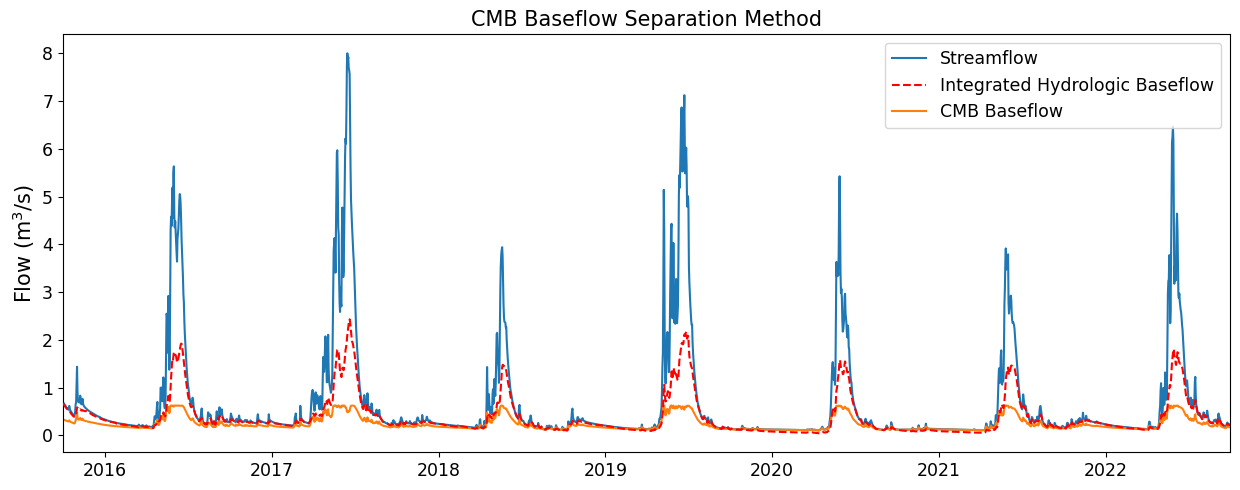

In [53]:
fig, ax = plt.subplots(figsize=(12.5, 5))

ax.plot(merged_df.index, merged_df['watershed boundary discharge [m3 s^-1]'], label='Streamflow')

# Compare against integrated hydrologic baseflow (if present in df)
if 'final_baseflow [m3 s^-1]' in df.columns:
    ax.plot(df.index, df['final_baseflow [m3 s^-1]'],
            label='Integrated Hydrologic Baseflow', color='red', linestyle='--', zorder=10)

ax.plot(merged_df.index, merged_df['MCB_baseflow_power_obsfit'], label='CMB Baseflow')

ax.set_xlim(pd.Timestamp('2015-10-01'), pd.Timestamp('2022-09-30'))


ax.set_ylabel(r'Flow (m$^3$/s)', fontsize=15)
ax.tick_params(axis='x', labelsize=12.5)
ax.tick_params(axis='y', labelsize=12.5)
ax.legend(fontsize=12.5)

plt.title('CMB Baseflow Separation Method', fontsize=15)
plt.tight_layout()
plt.savefig('figures/CMB_baseflow_simQ_obsfit.png', dpi=500)
plt.show()


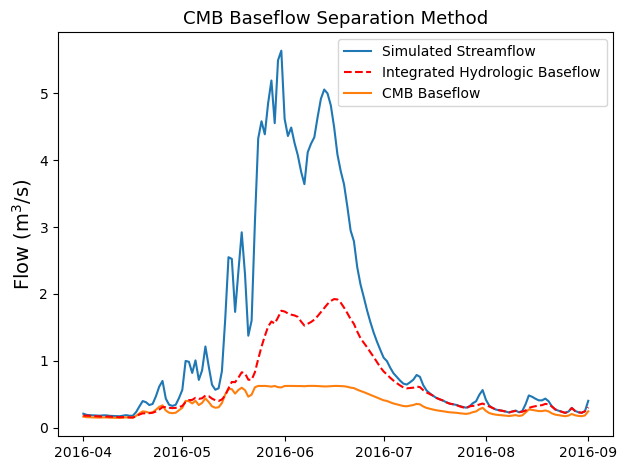

In [54]:
start_date = '2016-04-01'
end_date = '2016-09-01'

merged_df_zoom = merged_df.loc[start_date:end_date]
filtereddf = df.loc[start_date:end_date] if isinstance(df.index, pd.DatetimeIndex) else df

fig, ax = plt.subplots()

ax.plot(merged_df_zoom.index, merged_df_zoom['watershed boundary discharge [m3 s^-1]'], label='Simulated Streamflow')

if 'final_baseflow [m3 s^-1]' in df.columns:
    ax.plot(filtereddf.index, filtereddf['final_baseflow [m3 s^-1]'],
            label='Integrated Hydrologic Baseflow', color='red', linestyle='--', zorder=10)

ax.plot(merged_df_zoom.index, merged_df_zoom['MCB_baseflow_power_obsfit'], label='CMB Baseflow')

ax.set_ylabel(r'Flow (m$^3$/s)', fontsize=fontsize)
ax.legend()

plt.title('CMB Baseflow Separation Method', fontsize=13)


plt.tight_layout()
plt.savefig('figures/zoom_CMB_baseflow_simQ_obsfit.png', dpi=800)
plt.show()

In [55]:
start_date = '2016-10-01'
end_date = '2017-10-01'
merged_df_2017 = merged_df.loc[start_date:end_date]

max_baseflow_value = merged_df_2017['MCB_baseflow_power_obsfit'].max()
max_baseflow_date = merged_df_2017['MCB_baseflow_power_obsfit'].idxmax()

max_streamflow_value = merged_df_2017['watershed boundary discharge [m3 s^-1]'].max()
max_streamflow_date = merged_df_2017['watershed boundary discharge [m3 s^-1]'].idxmax()

print(f"Highest baseflow (2017): {max_baseflow_value} m³/s on {max_baseflow_date}")
print(f"Highest streamflow (2017): {max_streamflow_value} m³/s on {max_streamflow_date}")

Highest baseflow (2017): 0.6265866233879771 m³/s on 2017-06-08 00:00:00
Highest streamflow (2017): 8.002212708047631 m³/s on 2017-06-15 00:00:00


In [56]:
start_date = '2020-10-01'
end_date = '2021-10-01'
merged_df_2021 = merged_df.loc[start_date:end_date]

max_baseflow_value = merged_df_2021['MCB_baseflow_power_obsfit'].max()
max_baseflow_date = merged_df_2021['MCB_baseflow_power_obsfit'].idxmax()

max_streamflow_value = merged_df_2021['watershed boundary discharge [m3 s^-1]'].max()
max_streamflow_date = merged_df_2021['watershed boundary discharge [m3 s^-1]'].idxmax()

print(f"Highest baseflow (2021): {max_baseflow_value} m³/s on {max_baseflow_date}")
print(f"Highest streamflow (2021): {max_streamflow_value} m³/s on {max_streamflow_date}")

Highest baseflow (2021): 0.625084505977496 m³/s on 2021-05-27 00:00:00
Highest streamflow (2021): 3.916489722003254 m³/s on 2021-05-27 00:00:00


### Sensitivity test for CMB method by varying end members

In [57]:
ro_end_member = ro_end_member_obs
bf_end_member = bf_end_member_sim


In [58]:
# RO end members ±10%
ro_end_member_plus_10per = ro_end_member + (ro_end_member * 10 / 100)
ro_plus_value = int(round(ro_end_member_plus_10per))
col_ro_plus = f'MCB_baseflow_power_{ro_plus_value}'

ro_end_member_minus_10per = ro_end_member - (ro_end_member * 10 / 100)
ro_minus_value = int(round(ro_end_member_minus_10per))
col_ro_minus = f'MCB_baseflow_power_{ro_minus_value}'


In [59]:
# BF end members ±10%
bf_end_member_plus_10per = bf_end_member + (bf_end_member * 10 / 100)
bf_plus_value = int(round(bf_end_member_plus_10per))
col_bf_plus = f'MCB_baseflow_power_{bf_plus_value}'

bf_end_member_minus_10per = bf_end_member - (bf_end_member * 10 / 100)
bf_minus_value = int(round(bf_end_member_minus_10per))
col_bf_minus = f'MCB_baseflow_power_{bf_minus_value}'

In [60]:
# RO variations (use SC estimated from sim Q with obs-fit)
merged_df[col_ro_plus] = merged_df['watershed boundary discharge [m3 s^-1]'] * (
    (merged_df['interpolated_SC_power_obsfit'] - ro_end_member_plus_10per) / (bf_end_member - ro_end_member_plus_10per)
)

merged_df[col_ro_minus] = merged_df['watershed boundary discharge [m3 s^-1]'] * (
    (merged_df['interpolated_SC_power_obsfit'] - ro_end_member_minus_10per) / (bf_end_member - ro_end_member_minus_10per)
)

# BF variations
merged_df[col_bf_plus] = merged_df['watershed boundary discharge [m3 s^-1]'] * (
    (merged_df['interpolated_SC_power_obsfit'] - ro_end_member) / (bf_end_member_plus_10per - ro_end_member)
)

merged_df[col_bf_minus] = merged_df['watershed boundary discharge [m3 s^-1]'] * (
    (merged_df['interpolated_SC_power_obsfit'] - ro_end_member) / (bf_end_member_minus_10per - ro_end_member)
)

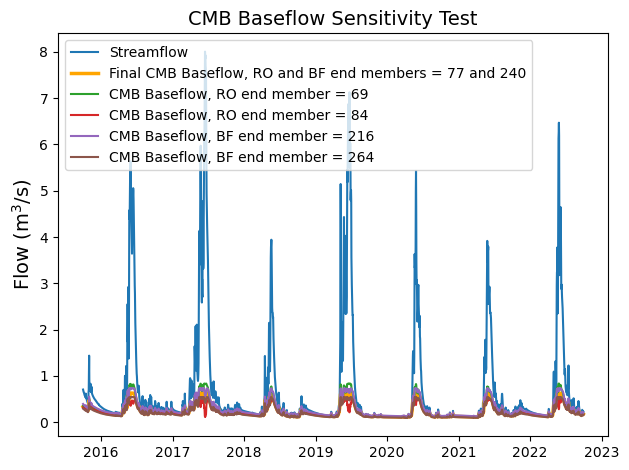

In [61]:
fig, ax = plt.subplots()

ax.plot(merged_df.index, merged_df['watershed boundary discharge [m3 s^-1]'], label='Streamflow')

# Final CMB baseflow (obs-fit)
ax.plot(merged_df.index, merged_df['MCB_baseflow_power_obsfit'], label='Final CMB Baseflow, RO and BF end members = 77 and 240', color='orange', linewidth=2.5)

ax.plot(merged_df.index, merged_df[col_ro_minus], label=f'CMB Baseflow, RO end member = {ro_minus_value}', color='tab:green')
ax.plot(merged_df.index, merged_df[col_ro_plus],  label=f'CMB Baseflow, RO end member = {ro_plus_value}', color='tab:red')
ax.plot(merged_df.index, merged_df[col_bf_minus], label=f'CMB Baseflow, BF end member = {bf_minus_value}', color='tab:purple')
ax.plot(merged_df.index, merged_df[col_bf_plus],  label=f'CMB Baseflow, BF end member = {bf_plus_value}', color='tab:brown')

ax.set_ylabel(r'Flow (m$^3$/s)', fontsize=fontsize)
ax.legend()
plt.title('CMB Baseflow Sensitivity Test', fontsize=fontsize)
plt.tight_layout()
plt.savefig('figures/obs_sensitivity_test_CMB.png', dpi=500)
plt.show()


In [62]:
start_date = '2015-10-01'
end_date = '2018-10-01'
merged_df_zoom_test = merged_df.loc[start_date:end_date]

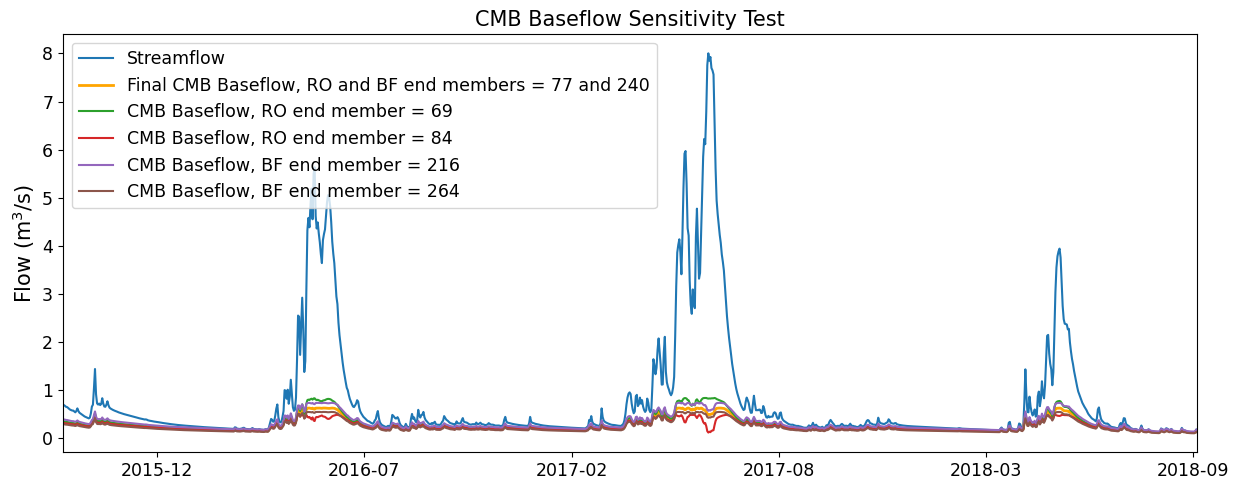

In [63]:


fig, ax = plt.subplots(figsize=(12.5,5))

ax.plot(merged_df_zoom_test.index, merged_df_zoom_test['watershed boundary discharge [m3 s^-1]'], label='Streamflow')

ax.plot(merged_df_zoom_test.index, merged_df_zoom_test['MCB_baseflow_power_obsfit'],label='Final CMB Baseflow, RO and BF end members = 77 and 240', color='orange', linewidth=2)

ax.plot(merged_df_zoom_test.index, merged_df_zoom_test[col_ro_minus], label=f'CMB Baseflow, RO end member = {ro_minus_value}', color='tab:green')
ax.plot(merged_df_zoom_test.index, merged_df_zoom_test[col_ro_plus],  label=f'CMB Baseflow, RO end member = {ro_plus_value}', color='tab:red')
ax.plot(merged_df_zoom_test.index, merged_df_zoom_test[col_bf_minus], label=f'CMB Baseflow, BF end member = {bf_minus_value}', color='tab:purple')
ax.plot(merged_df_zoom_test.index, merged_df_zoom_test[col_bf_plus],  label=f'CMB Baseflow, BF end member = {bf_plus_value}', color='tab:brown')

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

ax.set_xlim(pd.Timestamp('2015-10-01'), pd.Timestamp('2018-09-30'))
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(6))


ax.set_ylabel(r'Flow (m$^3$/s)', fontsize=15)
ax.tick_params(axis='x', labelsize=12.5)
ax.tick_params(axis='y', labelsize=12.5)
ax.legend(fontsize=12.5)


plt.title('CMB Baseflow Sensitivity Test', fontsize=15)


plt.tight_layout()
plt.savefig('figures/obs_sensitivity_test_CMB_2015-2018.png', dpi=500)
plt.show()

In [64]:
# This is applied if we are removing the simulated discharge-based CMB baseflow calculations
new_merged_df = merged_df.copy()
new_merged_df['MCB_baseflow_power'] = merged_df['MCB_baseflow_power_obsfit']


In [65]:
# Check negatives + also capture minimum value and the date(s) it occurs

negatives = {}

for col, label in zip(
    [col_ro_plus, col_ro_minus, col_bf_plus, col_bf_minus],
    [
        f"RO+10% = {ro_plus_value}",
        f"RO-10% = {ro_minus_value}",
        f"BF+10% = {bf_plus_value}",
        f"BF-10% = {bf_minus_value}",
    ],
):
    s = merged_df[col]

    has_neg = (s < 0).any()
    neg_count = (s < 0).sum()
    neg_rows = merged_df.loc[s < 0, [col]]  # keep only this column (cleaner)

    # Minimum value + day(s)
    min_val = s.min()
    min_days = s.index[s == min_val]  # can be 1 or multiple days
    min_rows = merged_df.loc[min_days, [col]]

    # Store results
    negatives[col] = {
        "label": label,
        "has_negative": has_neg,
        "count": int(neg_count),
        "rows_negative": neg_rows,
        "min_value": float(min_val),
        "min_days": min_days,
        "rows_min": min_rows,
    }

# Print summary for each column
for col, info in negatives.items():
    print(f"Column: {col} ({info['label']})")
    print(f"  Has negative values? {info['has_negative']}")
    print(f"  Count of negative values: {info['count']}")
    print(f"  Minimum value: {info['min_value']}")
    print(f"  Day(s) of minimum: {list(info['min_days'])}")
    print()

# If you still want the full list of negative days/values for one scenario (example: RO+10%)
negative_days_ro_plus = merged_df.index[merged_df[col_ro_plus] < 0]
negative_values_ro_plus = merged_df.loc[merged_df[col_ro_plus] < 0, col_ro_plus]

print("RO+10% negative days:", list(negative_days_ro_plus))
print("RO+10% negative values:")
print(negative_values_ro_plus)

# Minimum for RO+10% specifically (value + date(s))
min_ro_plus = merged_df[col_ro_plus].min()
min_days_ro_plus = merged_df.index[merged_df[col_ro_plus] == min_ro_plus]

print("\nRO+10% minimum value:", float(min_ro_plus))
print("RO+10% minimum day(s):", list(min_days_ro_plus))


Column: MCB_baseflow_power_84 (RO+10% = 84)
  Has negative values? False
  Count of negative values: 0
  Minimum value: 0.10769826784883449
  Day(s) of minimum: [Timestamp('2020-04-13 00:00:00')]

Column: MCB_baseflow_power_69 (RO-10% = 69)
  Has negative values? False
  Count of negative values: 0
  Minimum value: 0.10744585378730656
  Day(s) of minimum: [Timestamp('2020-04-13 00:00:00')]

Column: MCB_baseflow_power_264 (BF+10% = 264)
  Has negative values? False
  Count of negative values: 0
  Minimum value: 0.09378907224739662
  Day(s) of minimum: [Timestamp('2020-04-13 00:00:00')]

Column: MCB_baseflow_power_216 (BF-10% = 216)
  Has negative values? False
  Count of negative values: 0
  Minimum value: 0.1260876924189824
  Day(s) of minimum: [Timestamp('2020-04-13 00:00:00')]

RO+10% negative days: []
RO+10% negative values:
Series([], Name: MCB_baseflow_power_84, dtype: float64)

RO+10% minimum value: 0.10769826784883449
RO+10% minimum day(s): [Timestamp('2020-04-13 00:00:00')]


# (3) Digital Filter Method

## Calculating the recession constant using recession analysis:

In [66]:
df_digital=df

df_digital['decreasing_gw'] = df_digital['GW_discharge_new_dryperiod [m d^-1]'].diff().lt(0).astype(int)
df_digital['not_nan'] = df_digital['GW_discharge_new_dryperiod [m d^-1]'].notna().astype(int)
df_digital['decreasing_gw'] = df_digital['decreasing_gw'] * df_digital['not_nan']
df_digital['decreasing_gw_streak'] = df_digital['decreasing_gw'] * (df_digital['decreasing_gw'].groupby((df_digital['decreasing_gw'] != df_digital['decreasing_gw'].shift()).cumsum()).cumcount() + 1)



five_day_decrease_gw_periods = df_digital[df_digital['decreasing_gw_streak'] >= 5]
five_day_decrease_gw_periods['Qt'] = five_day_decrease_gw_periods['GW_discharge_new_dryperiod [m d^-1]']
five_day_decrease_gw_periods['Qt_plus_1'] = five_day_decrease_gw_periods['Qt'].shift(-1)
filtered_gw_df = five_day_decrease_gw_periods.dropna(subset=['Qt', 'Qt_plus_1'])

C:\Users\jihad\AppData\Local\Temp\ipykernel_36352\3543297436.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  five_day_decrease_gw_periods['Qt'] = five_day_decrease_gw_periods['GW_discharge_new_dryperiod [m d^-1]']
C:\Users\jihad\AppData\Local\Temp\ipykernel_36352\3543297436.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  five_day_decrease_gw_periods['Qt_plus_1'] = five_day_decrease_gw_periods['Qt'].shift(-1)


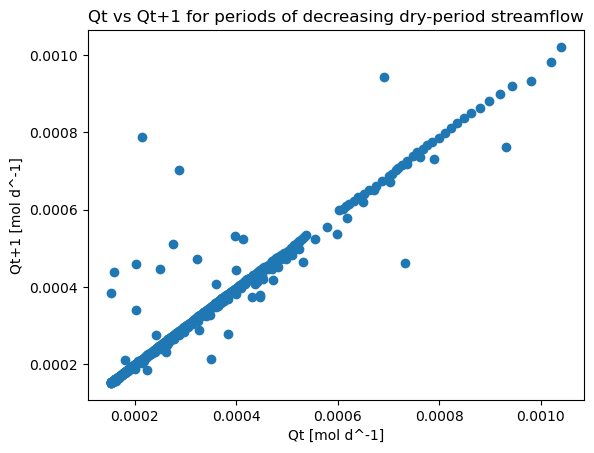

In [67]:
plt.scatter(filtered_gw_df['Qt'], filtered_gw_df['Qt_plus_1'])
plt.xlabel('Qt [mol d^-1]')
plt.ylabel('Qt+1 [mol d^-1]')
plt.title('Qt vs Qt+1 for periods of decreasing dry-period streamflow')
plt.savefig('figures/recession analysis', dpi=500)
plt.show()

In [68]:
X_gw = filtered_gw_df['Qt'].values.reshape(-1, 1)
y_gw = filtered_gw_df['Qt_plus_1'].values

reg_gw = LinearRegression(fit_intercept=False)
reg_gw.fit(X_gw, y_gw)
recession_constant_a_gw = reg_gw.coef_[0]
print(f"recession constant: {recession_constant_a_gw}")

recession constant: 0.9881641114040819


## Calculating BFImax using LH method:

In [69]:
df_BFI = df_digital
df_BFI['watershed boundary discharge [m^3/s]'] = df_BFI['watershed boundary discharge [m^3/d]'] / 86400
series = df_BFI['watershed boundary discharge [m^3/s]']

if not isinstance(series.index, pd.DatetimeIndex):
    series.index = pd.to_datetime(series.index)

Q, date = clean_streamflow(series)

a=recession_constant_a_gw


b_LH = LH(Q)


BFImax = param_calibrate(np.arange(0.001, 1, 0.001), Eckhardt, Q, b_LH, a)

print(f"BFImax: {BFImax}")

BFImax: 0.763


## Calculating and plotting digital filter method baseflow using a 'multi-method baseflow separation function'

In [70]:
xie_baseflow=df

In [71]:
def clean_streamflow(series):
    if not isinstance(series, pd.Series):
        raise ValueError("Input must be a pandas Series")
    if not isinstance(series.index, pd.DatetimeIndex):
        raise ValueError("Series index must be a DateTimeIndex")

    date = series.index
    Q = series.values.astype(float)


    has_value = np.isfinite(Q)
    date = date[has_value]
    Q = np.abs(Q[has_value])

    water_years = np.where(date.month >= 10, date.year + 1, date.year)

    wy_unique, wy_counts = np.unique(water_years, return_counts=True)

    valid_wy = wy_unique[wy_counts >= 120]

    keep = np.isin(water_years, valid_wy)

    return Q[keep], date[keep]

    a=recession_constant_a_gw
BFImax=BFImax
# area=20.4 mi square
area=53.2 #km2
ice = None
BFImax

0.763

In [72]:
def single(series, area=area, ice=None, method='all', return_kge=True):
    Q, date = clean_streamflow(series)
    method = format_method(method)

    b_LH = LH(Q)
    b = pd.DataFrame(np.nan, index=date, columns=method)
    for m in method:
        if m == 'UKIH':
            b[m] = UKIH(Q, b_LH)

        if m == 'Local':
            b[m] = Local(Q, b_LH, area)

        if m == 'Fixed':
            b[m] = Fixed(Q, area)

        if m == 'Slide':
            b[m] = Slide(Q, area)

        if m == 'LH':
            b[m] = b_LH



        if m == 'Eckhardt':
            # BFImax = maxmium_BFI(Q, b_LH, a, date)
            # BFImax = param_calibrate(np.arange(0.001, 1, 0.001), Eckhardt, Q, b_LH, a)
            b[m] = Eckhardt(Q, b_LH, a, BFImax)


    return b, None
series = xie_baseflow['watershed boundary discharge [m^3/s]']
b, _ = single(series, area=area, ice=ice, method='all', return_kge=False)

b = b[b.index >= '2015-10-01']

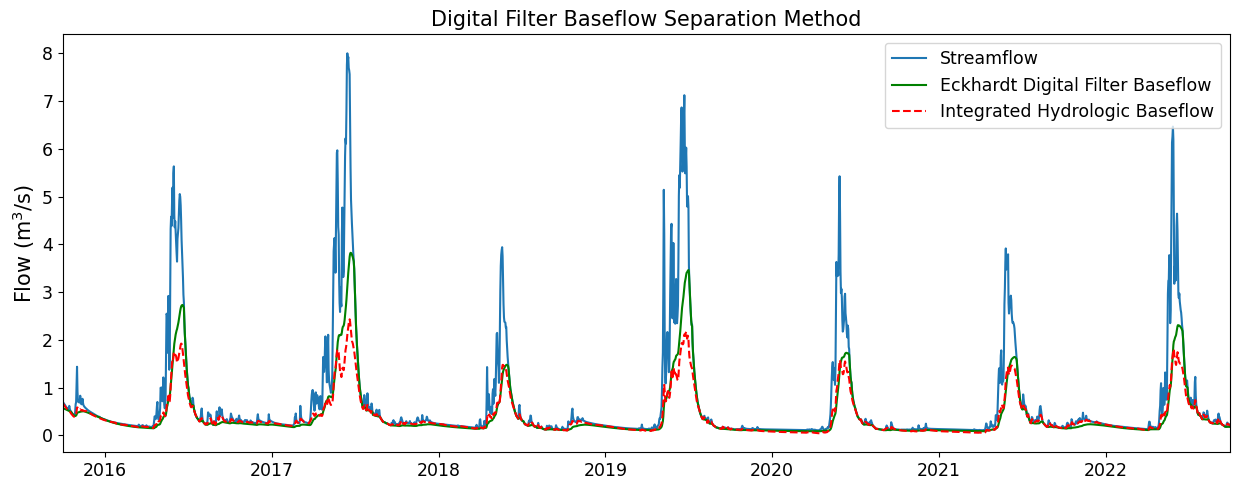

In [73]:
plt.figure(figsize=(12.5, 5))  

plt.plot(xie_baseflow.index, xie_baseflow['watershed boundary discharge [m^3/s]'], label='Streamflow')
plt.plot(b.index, b['Eckhardt'], label='Eckhardt Digital Filter Baseflow', color='green')
plt.plot(df.index , df['final_baseflow [m3 s^-1]'], label='Integrated Hydrologic Baseflow', color='red', linestyle='--')

plt.legend(fontsize = 11)
plt.title('Digital Filter Baseflow Separation Method', fontsize = 15)
plt.ylabel(r'Flow (m$^3$/s)', fontsize = fontsize)
plt.xlim(pd.Timestamp('2015-10-01'), pd.Timestamp('2022-09-30'))




plt.ylabel(r'Flow (m$^3$/s)', fontsize=15)
plt.tick_params(axis='x', labelsize=12.5)
plt.tick_params(axis='y', labelsize=12.5)
plt.legend(fontsize=12.5)



plt.tight_layout()

plt.savefig('figures/Digital Filter Baseflow Separation Method', dpi=500)
plt.show()


In [74]:
startdate = '2016-04-01'
enddate = '2016-09-01'
filtered_xie_baseflow = xie_baseflow[(xie_baseflow.index >= startdate) & (xie_baseflow.index <= enddate)]
filtered_b = b[(b.index >= startdate) & (b.index <= enddate)]
filtered_df = df[(df.index >= startdate) & (df.index <= enddate)]

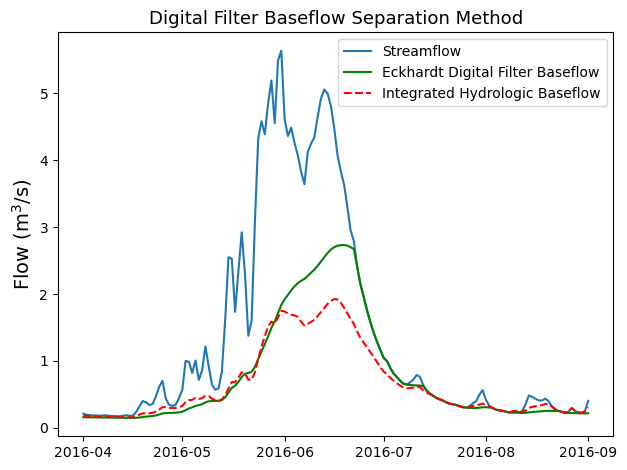

In [75]:
plt.figure()  

plt.plot(filtered_xie_baseflow.index, filtered_xie_baseflow['watershed boundary discharge [m^3/s]'], label='Streamflow')
plt.plot(filtered_b.index, filtered_b['Eckhardt'], label='Eckhardt Digital Filter Baseflow', color='green')
plt.plot(filtered_df.index , filtered_df['final_baseflow [m3 s^-1]'], label='Integrated Hydrologic Baseflow', color='red', linestyle='--')

plt.legend()
plt.ylabel(r'Flow (m$^3$/s)', fontsize = fontsize)
plt.title('Digital Filter Baseflow Separation Method', fontsize = 13)
plt.tight_layout()

plt.savefig('figures/Digital Filter Baseflow Separation Method_2016', dpi=500)
plt.show()

# Sensitivity test of Digital Filter Method: 
#### The sensitivity test for the digital filter method is applied for different BFImax values (+-0.1 and 0.2 of BFImax) using the "multi-method baseflow separation function".

# Find the baseflow when BFImax=0.563

In [76]:
def clean_streamflow(series):
    if not isinstance(series, pd.Series):
        raise ValueError("Input must be a pandas Series")
    if not isinstance(series.index, pd.DatetimeIndex):
        raise ValueError("Series index must be a DateTimeIndex")

    date = series.index
    Q = series.values.astype(float)

    has_value = np.isfinite(Q)
    date = date[has_value]
    Q = np.abs(Q[has_value])

    # Water year: Oct–Sep belongs to the NEXT calendar year 
    water_years = np.where(date.month >= 10, date.year + 1, date.year)

    # Count valid entries per water year and keep WYs with at least 120 days
    wy_unique, wy_counts = np.unique(water_years, return_counts=True)
    valid_wy = wy_unique[wy_counts >= 120]

    keep = np.isin(water_years, valid_wy)

    return Q[keep], date[keep]



a = recession_constant_a_gw
BFImax_6 = 0.563
# area = 20.4
area = 53.2 #km2
ice = None

In [77]:
def single(series, area=area, ice=None, method='all', return_kge=False):
    Q, date = clean_streamflow(series)
    method = format_method(method)

    b_LH = LH(Q)
    bminus20 = pd.DataFrame(np.nan, index=date, columns=method)
    for m in method:
        if m == 'UKIH':
            bminus20[m] = UKIH(Q, b_LH)
        if m == 'Local':
            bminus20[m] = Local(Q, b_LH, area)
        if m == 'Fixed':
            bminus20[m] = Fixed(Q, area)
        if m == 'Slide':
            bminus20[m] = Slide(Q, area)
        if m == 'LH':
            bminus20[m] = b_LH
        if m == 'Eckhardt':
            bminus20[m] = Eckhardt(Q, b_LH, a, BFImax_6)

    return bminus20, None

series = xie_baseflow['watershed boundary discharge [m^3/s]']
bminus20, _ = single(series, area=area, ice=ice, method='all', return_kge=False)


# Find the baseflow when BFImax=0.963

In [78]:
def clean_streamflow(series):
    if not isinstance(series, pd.Series):
        raise ValueError("Input must be a pandas Series")
    if not isinstance(series.index, pd.DatetimeIndex):
        raise ValueError("Series index must be a DateTimeIndex")

    date = series.index
    Q = series.values.astype(float)

    has_value = np.isfinite(Q)
    date = date[has_value]
    Q = np.abs(Q[has_value])

    # Water year: Oct–Sep belongs to the NEXT calendar year 
    water_years = np.where(date.month >= 10, date.year + 1, date.year)

    # Count valid entries per water year and keep WYs with at least 120 days
    wy_unique, wy_counts = np.unique(water_years, return_counts=True)
    valid_wy = wy_unique[wy_counts >= 120]

    keep = np.isin(water_years, valid_wy)

    return Q[keep], date[keep]



a = recession_constant_a_gw
BFImax_20 = 0.963
# area = 20.4
area = 53.2 #km2
ice = None

In [79]:
def single(series, area=area, ice=None, method='all', return_kge=False):
    Q, date = clean_streamflow(series)
    method = format_method(method)

    b_LH = LH(Q)
    bplus20 = pd.DataFrame(np.nan, index=date, columns=method)
    for m in method:
        if m == 'UKIH':
            bplus20[m] = UKIH(Q, b_LH)
        if m == 'Local':
            bplus20[m] = Local(Q, b_LH, area)
        if m == 'Fixed':
            bplus20[m] = Fixed(Q, area)
        if m == 'Slide':
            bplus20[m] = Slide(Q, area)
        if m == 'LH':
            bplus20[m] = b_LH
        if m == 'Eckhardt':
            bplus20[m] = Eckhardt(Q, b_LH, a, BFImax_20)

    return bplus20, None

series = xie_baseflow['watershed boundary discharge [m^3/s]']
bplus20, _ = single(series, area=area, ice=ice, method='all', return_kge=False)


#### Find the baseflow when BFImax=0.663

In [80]:
def clean_streamflow(series):
    if not isinstance(series, pd.Series):
        raise ValueError("Input must be a pandas Series")
    if not isinstance(series.index, pd.DatetimeIndex):
        raise ValueError("Series index must be a DateTimeIndex")

    date = series.index
    Q = series.values.astype(float)

    has_value = np.isfinite(Q)
    date = date[has_value]
    Q = np.abs(Q[has_value])

    # Water year: Oct–Sep belongs to the NEXT calendar year 
    water_years = np.where(date.month >= 10, date.year + 1, date.year)

    # Count valid entries per water year and keep WYs with at least 120 days
    wy_unique, wy_counts = np.unique(water_years, return_counts=True)
    valid_wy = wy_unique[wy_counts >= 120]

    keep = np.isin(water_years, valid_wy)

    return Q[keep], date[keep]



a = recession_constant_a_gw
BFImax_minus_10 = 0.663
# area = 20.4
area = 53.2 #km2
ice = None

In [81]:
def single(series, area=area, ice=None, method='all', return_kge=False):
    Q, date = clean_streamflow(series)
    method = format_method(method)

    b_LH = LH(Q)
    b6 = pd.DataFrame(np.nan, index=date, columns=method)
    for m in method:
        if m == 'UKIH':
            b6[m] = UKIH(Q, b_LH)
        if m == 'Local':
            b6[m] = Local(Q, b_LH, area)
        if m == 'Fixed':
            b6[m] = Fixed(Q, area)
        if m == 'Slide':
            b6[m] = Slide(Q, area)
        if m == 'LH':
            b6[m] = b_LH
        if m == 'Eckhardt':
            b6[m] = Eckhardt(Q, b_LH, a, BFImax_minus_10)

    return b6, None

series = xie_baseflow['watershed boundary discharge [m^3/s]']
b6, _ = single(series, area=area, ice=ice, method='all', return_kge=False)


#### Find the baseflow when BFImax = 0.863

In [82]:
a = recession_constant_a_gw
BFImax_8 = 0.863
# area = 20.4
area = 53.2 #km2
ice = None

def clean_streamflow(series):
    if not isinstance(series, pd.Series):
        raise ValueError("Input must be a pandas Series")
    if not isinstance(series.index, pd.DatetimeIndex):
        raise ValueError("Series index must be a DateTimeIndex")

    date = series.index
    Q = series.values.astype(float)


    has_value = np.isfinite(Q)
    date = date[has_value]
    Q = np.abs(Q[has_value])

    # Water year: Oct–Sep belongs to the NEXT calendar year
    water_years = np.where(date.month >= 10, date.year + 1, date.year)

    # Count valid entries per water year and keep WYs with at least 120 days
    wy_unique, wy_counts = np.unique(water_years, return_counts=True)
    valid_wy = wy_unique[wy_counts >= 120]

    keep = np.isin(water_years, valid_wy)

    return Q[keep], date[keep]

In [83]:
def single(series, area=area, ice=None, method='all', return_kge=False):
    Q, date = clean_streamflow(series)
    method = format_method(method)

    b_LH = LH(Q)
    b8 = pd.DataFrame(np.nan, index=date, columns=method)
    for m in method:
        if m == 'UKIH':
            b8[m] = UKIH(Q, b_LH)
        if m == 'Local':
            b8[m] = Local(Q, b_LH, area)
        if m == 'Fixed':
            b8[m] = Fixed(Q, area)
        if m == 'Slide':
            b8[m] = Slide(Q, area)
        if m == 'LH':
            b8[m] = b_LH
        if m == 'Eckhardt':
            b8[m] = Eckhardt(Q, b_LH, a, BFImax_8)

    return b8, None

series = xie_baseflow['watershed boundary discharge [m^3/s]']
b8, _ = single(series, area=area, ice=ice, method='all', return_kge=False)


b8 = b8[b8.index >= '2015-10-01']

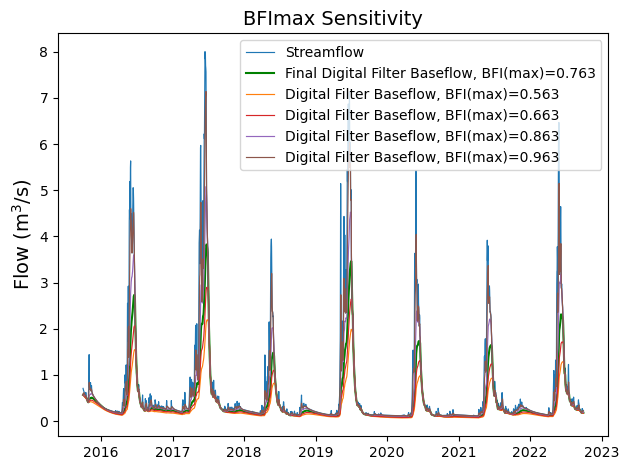

In [84]:
plt.figure()  

plt.plot(xie_baseflow.index, xie_baseflow['watershed boundary discharge [m^3/s]'], label='Streamflow', linewidth=0.85)
# plt.plot(df.index , df['final_baseflow [m3 s^-1]'], label='Numerical Method Baseflow',color = 'red', linewidth=0.85, linestyle='--', zorder=10)
plt.plot(b.index, b['Eckhardt'], label='Final Digital Filter Baseflow, BFI(max)=0.763', linewidth=1.5, color='green')
plt.plot(bminus20.index, bminus20['Eckhardt'], label='Digital Filter Baseflow, BFI(max)=0.563', linewidth=0.85, color='tab:orange')
plt.plot(b6.index, b6['Eckhardt'], label='Digital Filter Baseflow, BFI(max)=0.663', linewidth=0.85, color='tab:red')
plt.plot(b8.index, b8['Eckhardt'], label='Digital Filter Baseflow, BFI(max)=0.863', linewidth=0.85, color='tab:purple')
plt.plot(bplus20.index, bplus20['Eckhardt'], label='Digital Filter Baseflow, BFI(max)=0.963', linewidth=0.85, color='tab:brown')



plt.legend()
plt.title('BFImax Sensitivity', fontsize = fontsize)
plt.ylabel(r'Flow (m$^3$/s)', fontsize = fontsize)
plt.tight_layout()
plt.savefig('figures/BFImax_sensitivity', dpi=500)
plt.show()



In [85]:
# Ensure datetime indexes
for _obj in [xie_baseflow, df, bplus20, b8, b, b6, bminus20]:
    if not isinstance(_obj.index, pd.DatetimeIndex):
        _obj.index = pd.to_datetime(_obj.index)

# compute yearly BFI (%) on water year ending Sep
def yearly_bfi_stats(baseflow_series, streamflow_series):
    aligned = pd.concat(
        [baseflow_series.rename('baseflow'),
         streamflow_series.rename('streamflow')],
        axis=1, join='inner'
    )

    bf_y = aligned['baseflow'].resample('YE-SEP').sum(min_count=1)
    sf_y = aligned['streamflow'].resample('YE-SEP').sum(min_count=1)

    bfi_y = (bf_y / sf_y) * 100
    return bfi_y, bfi_y.mean(), bfi_y.std()

# Compute for the three Eckhardt runs
bfi_bplus20,  mean_bplus20,  std_bplus20  = yearly_bfi_stats(bplus20['Eckhardt'], xie_baseflow['watershed boundary discharge [m^3/s]'])
bfi_b8,  mean_b8,  std_b8  = yearly_bfi_stats(b8['Eckhardt'], xie_baseflow['watershed boundary discharge [m^3/s]'])
bfi_b,   mean_b,   std_b   = yearly_bfi_stats(b['Eckhardt'],  xie_baseflow['watershed boundary discharge [m^3/s]'])
bfi_b6,  mean_b6,  std_b6  = yearly_bfi_stats(b6['Eckhardt'], xie_baseflow['watershed boundary discharge [m^3/s]'])
bfi_bminus20,  mean_bminus20,  std_bminus20  = yearly_bfi_stats(bminus20['Eckhardt'], xie_baseflow['watershed boundary discharge [m^3/s]'])



# Assemble results table
bfi_tbl = pd.DataFrame({
    'BFI BFImax=0.963': bfi_bplus20,
    'BFI BFImax=0.863': bfi_b8,
    'BFI BFImax=0.763': bfi_b,
    'BFI BFImax=0.663': bfi_b6,
    'BFI BFImax=0.563': bfi_bminus20
})

# Make the index just the water year (e.g., '2016')
bfi_tbl.index = bfi_tbl.index.year.astype(str)

# Add summary rows
bfi_tbl.loc['Mean (%)'] = [mean_bplus20, mean_b8, mean_b, mean_b6, mean_bminus20]
bfi_tbl.loc['Std (%)']  = [std_bplus20, std_b8,  std_b,  std_b6, std_bminus20]

bfi_tbl


,BFI BFImax=0.963,BFI BFImax=0.863,BFI BFImax=0.763,BFI BFImax=0.663,BFI BFImax=0.563
datetime,,,,,
2016,90.009461,75.604260,63.913978,55.107633,48.016968
2017,88.480350,73.255257,61.861110,51.326348,42.624084
2018,89.497449,75.812600,64.580180,55.788528,48.413784
2019,87.972221,72.731370,59.414844,48.897801,39.990937
2020,88.771746,73.192794,60.686655,50.857011,43.004458
2021,89.647358,73.896100,61.194122,51.479898,43.690886
2022,88.023971,74.315253,62.339625,52.711636,44.981428
Mean (%),88.914651,74.115376,61.998645,52.309837,44.388935
Std (%),0.812983,1.203593,1.803359,2.432390,3.015908


In [86]:
startdate = '2015-10-01'
enddate = '2018-10-01'
filtered_xie_baseflow  = xie_baseflow.loc[startdate:enddate]
b8  = b8.loc[startdate:enddate]
b6  = b6.loc[startdate:enddate]
b_org  = b.loc[startdate:enddate]
bminus20 = bminus20.loc[startdate:enddate]
bplus20 = bplus20.loc[startdate:enddate]

filt_combined_df=df.loc[startdate:enddate]

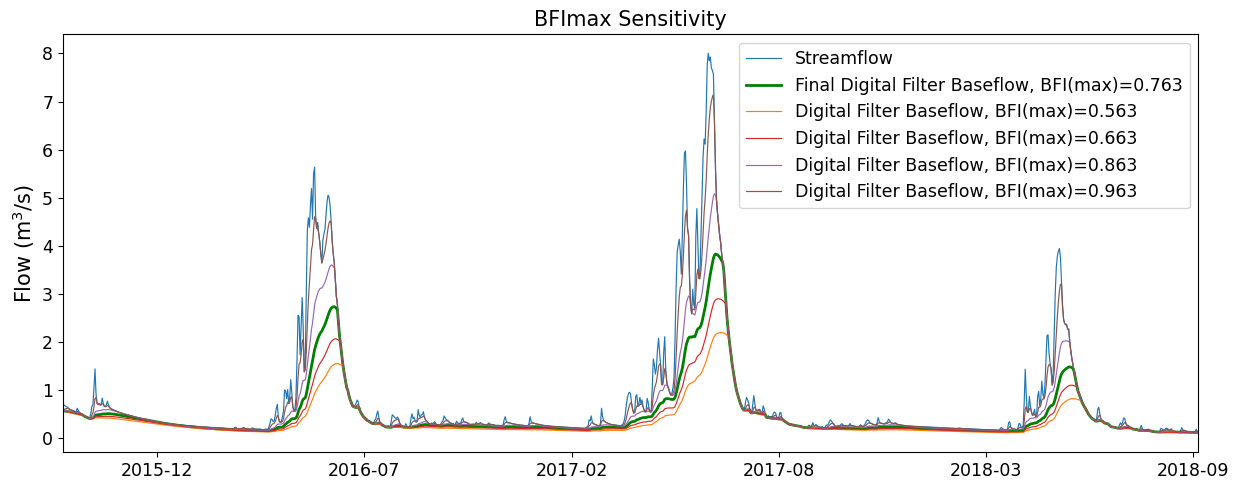

In [87]:
plt.figure(figsize=(12.5,5))  

plt.plot(filtered_xie_baseflow.index, filtered_xie_baseflow['watershed boundary discharge [m^3/s]'], label='Streamflow', linewidth=0.85)
# plt.plot(filt_combined_df.index, filt_combined_df['final_baseflow [m3 s^-1]'], label='Numerical Method Baseflow',color = 'red', linewidth=0.85, linestyle='--', zorder=10)

plt.plot(b_org.index, b_org['Eckhardt'], label='Final Digital Filter Baseflow, BFI(max)=0.763', color='green', linewidth=2)
x
plt.plot(b6.index, bminus20['Eckhardt'], label='Digital Filter Baseflow, BFI(max)=0.563', linewidth=0.85, color='tab:orange')
plt.plot(b6.index, b6['Eckhardt'], label='Digital Filter Baseflow, BFI(max)=0.663', linewidth=0.85, color='tab:red')
plt.plot(b8.index, b8['Eckhardt'], label='Digital Filter Baseflow, BFI(max)=0.863', linewidth=0.85, color='tab:purple')
plt.plot(b6.index, bplus20['Eckhardt'], label='Digital Filter Baseflow, BFI(max)=0.963', linewidth=0.85, color='tab:brown')


ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))


plt.xlim(pd.Timestamp('2015-10-01'), pd.Timestamp('2018-10-01'))




plt.tick_params(axis='x', labelsize=12.5)
plt.tick_params(axis='y', labelsize=12.5)






plt.title('BFImax Sensitivity', fontsize = 15)

plt.legend(fontsize = 12.5)
plt.ylabel(r'Flow (m$^3$/s)', fontsize = 15)
plt.tight_layout()
plt.savefig('figures/BFI_max Sensitivity Test_2015-2018', dpi=500)
plt.show()




## (4) UKIH method

#### To calculate the baseflow for UKIH, we used 'baseflow.separation' function. In the cell bellow, we added extra dummy data before 2015 to make sure the function works well and separate the baseflow without errors. Our correct data starts from Sep 01, 2015, and it will not be affected. 

In [88]:
UKIH_streamflow=df
UKIH_streamflow = UKIH_streamflow[['watershed boundary discharge [m^3/s]']]

col = 'watershed boundary discharge [m^3/s]'

# Define padding period
real_start = UKIH_streamflow.index.min()
pad_start = pd.Timestamp('2014-12-31')
pad_end = real_start - pd.Timedelta(days=1)

pad_index = pd.date_range(start=pad_start, end=pad_end, freq='D')

# Choose flow value and ramping
ramp_days = 7
flat_days = len(pad_index) - ramp_days

# Set all dummy values around 0.5
flat_part = np.full(flat_days, 0.5)

# Ramp up from 0.5 to real flow on 2015-10-01
real_val = UKIH_streamflow.loc[real_start, col]
ramp_part = np.linspace(0.5, real_val, ramp_days)

# Combine both
dummy_values = np.concatenate([flat_part, ramp_part])
dummy_streamflow = pd.DataFrame({col: dummy_values}, index=pad_index)

# Combine dummy + real streamflow
padded_streamflow = pd.concat([dummy_streamflow, UKIH_streamflow])
padded_streamflow = padded_streamflow.sort_index()

# Run separation
UKIH_sep_full = baseflow.separation(padded_streamflow)


100%|██████████| 1/1 [00:09<00:00,  9.85s/it]


In [89]:

bf_ukih = UKIH_sep_full['UKIH']
bf_ukih = bf_ukih[bf_ukih.index >= '2015-10-01']

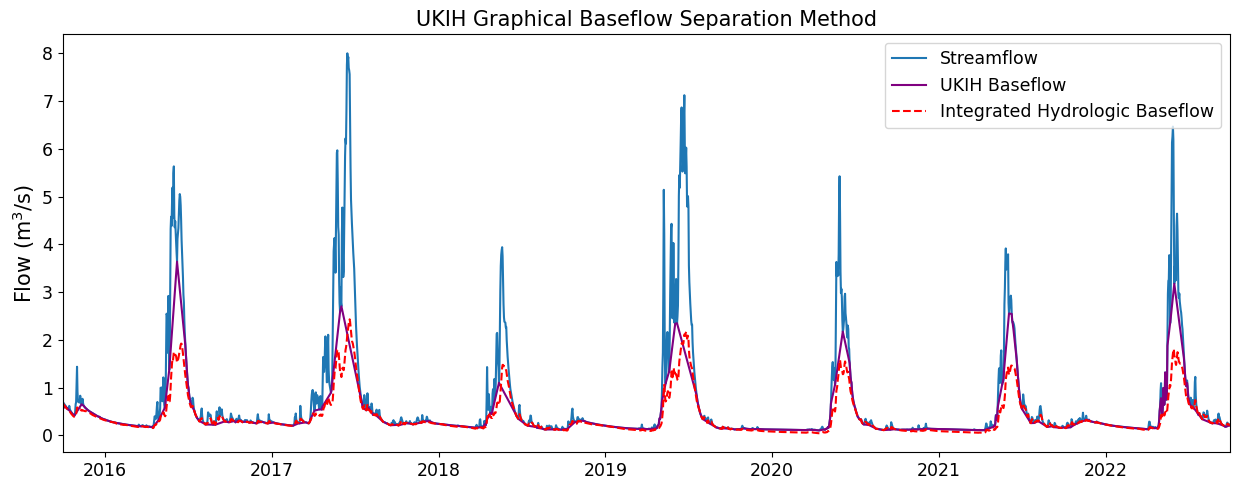

In [90]:
plt.figure(figsize=(12.5, 5))

plt.plot(UKIH_streamflow.index, UKIH_streamflow['watershed boundary discharge [m^3/s]'], label='Streamflow')
plt.plot(bf_ukih.index, bf_ukih['watershed boundary discharge [m^3/s]'], label='UKIH Baseflow', color='purple')
plt.plot(df.index , df['final_baseflow [m3 s^-1]'], label='Integrated Hydrologic Baseflow', color='red', linestyle='--')

# Adding labels and title
plt.ylabel(r'Flow (m$^3$/s)', fontsize = 15)
plt.title('UKIH Graphical Baseflow Separation Method', fontsize = 15)

plt.xlim(pd.Timestamp('2015-10-01'), pd.Timestamp('2022-09-30'))


plt.tick_params(axis='x', labelsize=12.5)
plt.tick_params(axis='y', labelsize=12.5)




# Adding legend
plt.legend(fontsize=12.5)
plt.tight_layout()
plt.savefig('figures/UKIH Graphical Baseflow Separation Method.png', dpi = 500)
plt.show()




In [91]:
startdate = '2016-04-01'
enddate = '2016-09-01'
filtered_UKIH_streamflow = UKIH_streamflow[(UKIH_streamflow.index >= startdate) & (UKIH_streamflow.index <= enddate)]
filtered_bf_ukih = bf_ukih[(bf_ukih.index >= startdate) & (bf_ukih.index <= enddate)]

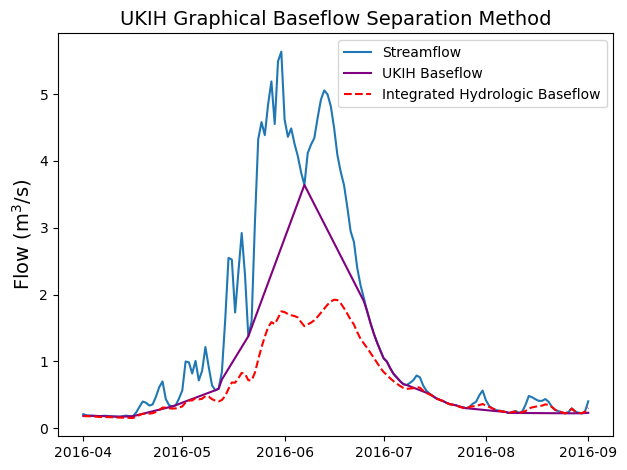

In [92]:
plt.figure()

plt.plot(filtered_UKIH_streamflow.index, filtered_UKIH_streamflow['watershed boundary discharge [m^3/s]'], label='Streamflow')
plt.plot(filtered_bf_ukih.index, filtered_bf_ukih['watershed boundary discharge [m^3/s]'], label='UKIH Baseflow', color= 'purple')
plt.plot(filtereddf.index , filtereddf['final_baseflow [m3 s^-1]'], label='Integrated Hydrologic Baseflow', color='red', linestyle='--')


# Adding labels and title
plt.ylabel(r'Flow (m$^3$/s)', fontsize = fontsize)
plt.title('UKIH Graphical Baseflow Separation Method', fontsize = fontsize)

plt.tight_layout()
# Adding legend
plt.legend()
plt.savefig('figures/UKIH Graphical Baseflow Separation Method_zoom.png', dpi = 500)
plt.show()

#### Plotting turning points

In [93]:
# Extract baseflow series
bf_series = filtered_bf_ukih['watershed boundary discharge [m^3/s]']
bf_index = filtered_bf_ukih.index

# Compute slope between points
slope = np.diff(bf_series)

# Define a slope change threshold
threshold = 0.001 

# Detect slope change above threshold
slope_diff = np.diff(slope)
significant_change = np.abs(slope_diff) > threshold

# Get indices where slope changes significantly
turning_idx = np.where(significant_change)[0] + 1  # +1 for correct index shift

# Extract dates and values of turning points
turning_dates = bf_index[turning_idx]
turning_values = bf_series.iloc[turning_idx]


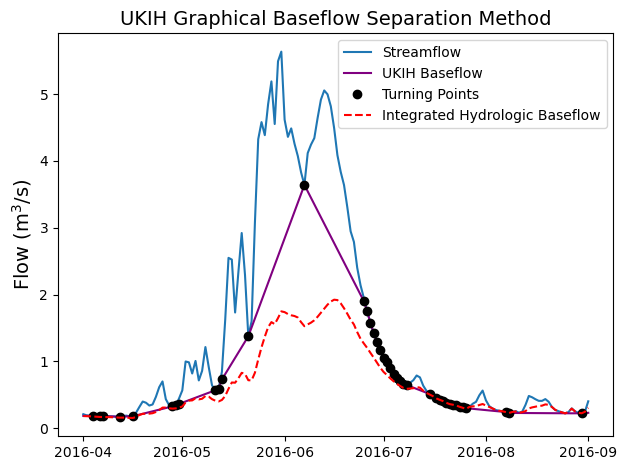

In [94]:
plt.figure()

# Streamflow
plt.plot(filtered_UKIH_streamflow.index,
         filtered_UKIH_streamflow['watershed boundary discharge [m^3/s]'],
         label='Streamflow')

# UKIH baseflow line
plt.plot(bf_index, bf_series, label='UKIH Baseflow', color='purple')

# Turning point markers only
plt.plot(turning_dates, turning_values, 'ko', markersize=6, label='Turning Points')


plt.plot(filtereddf.index,
         filtereddf['final_baseflow [m3 s^-1]'],
         label='Integrated Hydrologic Baseflow', color='red', linestyle='--')

plt.title('UKIH Graphical Baseflow Separation Method', fontsize = fontsize)
plt.ylabel(r'Flow (m$^3$/s)', fontsize=fontsize)
plt.tight_layout()
plt.legend()
plt.savefig('figures/UKIH Turning Points Onlye.png', dpi=500)
plt.show()


In [95]:
col = "watershed boundary discharge [m^3/s]"

def ukih_custom_from_series(q_series: pd.Series, N: int = 5, factor: float = 1.11) -> pd.DataFrame:
    q = q_series.dropna().copy()
    idx = q.index
    Q = q.values.astype(float)

    block_end = (len(Q) // N) * N
    if block_end < 3 * N:
        raise ValueError(f"Not enough data for UKIH with N={N} (need at least 3 full blocks).")

    Q_use = Q[:block_end]
    idx_use = idx[:block_end]

    # 1) minima in each N-day block
    blocks = Q_use.reshape(-1, N)
    argmin_in_block = np.argmin(blocks, axis=1)
    block_starts = np.arange(0, block_end, N)
    min_pos = block_starts + argmin_in_block
    qmins = Q_use[min_pos]

    # 2-3) turning points with 1.11 rule
    turn_ids = []
    for k in range(1, len(qmins) - 1):
        if (qmins[k] <= factor * qmins[k - 1]) and (qmins[k] <= factor * qmins[k + 1]):
            turn_ids.append(k)

    if len(turn_ids) < 2:
        raise ValueError(f"Too few turning points for N={N}. Increase padding or reduce N.")

    turn_pos = min_pos[turn_ids]
    turn_times = idx_use[turn_pos]
    turn_vals = Q_use[turn_pos]

    # 4) linear interpolation of turning points
    bf = pd.Series(index=idx_use, dtype=float)
    bf.loc[turn_times] = turn_vals
    bf = bf.interpolate(method="time")

    # extend ends flat
    first_i = bf.index.get_loc(turn_times[0])
    last_i  = bf.index.get_loc(turn_times[-1])
    bf.iloc[:first_i] = turn_vals[0]
    bf.iloc[last_i + 1:] = turn_vals[-1]

    # cap baseflow so BF <= Q
    bf = np.minimum(bf.values, Q_use)
    bf = pd.Series(bf, index=idx_use, name=col)

    # return in the same "DataFrame with column col" style as your code
    return pd.DataFrame({col: bf})


# --- compute UKIH for N=3,10,15 using the padded streamflow ---
q_padded = padded_streamflow[col]

bf_ukih_3  = ukih_custom_from_series(q_padded, N=3)
bf_ukih_4  = ukih_custom_from_series(q_padded, N=4)
bf_ukih_6  = ukih_custom_from_series(q_padded, N=6)
bf_ukih_10 = ukih_custom_from_series(q_padded, N=10)
bf_ukih_15 = ukih_custom_from_series(q_padded, N=15)

In [96]:
# trim to real period
start_real = "2015-10-01"
bf_ukih_3  = bf_ukih_3.loc[bf_ukih_3.index >= start_real]
bf_ukih_4  = bf_ukih_4.loc[bf_ukih_4.index >= start_real]
bf_ukih_6  = bf_ukih_6.loc[bf_ukih_6.index >= start_real]
bf_ukih_10 = bf_ukih_10.loc[bf_ukih_10.index >= start_real]
bf_ukih_15 = bf_ukih_15.loc[bf_ukih_15.index >= start_real]


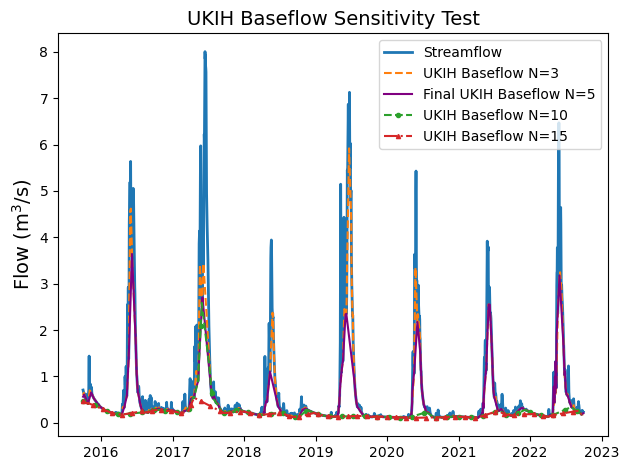

In [97]:
# --- one figure: streamflow + UKIH (5/10/15) + numerical baseflow ---
plt.figure()

plt.plot(UKIH_streamflow.index, UKIH_streamflow[col], label="Streamflow", linewidth=2)
plt.plot(bf_ukih_3.index, bf_ukih_3[col], label="UKIH Baseflow N=3", color="tab:orange", linestyle="--")
# plt.plot(bf_ukih_4.index, bf_ukih_4[col], label="UKIH Baseflow N=4")
plt.plot(bf_ukih.index, bf_ukih['watershed boundary discharge [m^3/s]'], label='Final UKIH Baseflow N=5', color='purple')
# plt.plot(bf_ukih_6.index, bf_ukih_6[col], label="UKIH Baseflow N=6")
plt.plot(bf_ukih_10.index, bf_ukih_10[col], label="UKIH Baseflow N=10", color = "tab:green", linestyle="--", marker="o", markevery=60, markersize=3)
plt.plot(bf_ukih_15.index, bf_ukih_15[col], label="UKIH Baseflow N=15", color="tab:red", linestyle="-.", marker="^", markevery=50, markersize=3)
# plt.plot(df.index, df["final_baseflow [m3 s^-1]"], label="Numerical baseflow", linestyle="--")

plt.ylabel(r"Flow (m$^3$/s)", fontsize=fontsize)
plt.title("UKIH Baseflow Sensitivity Test", fontsize=fontsize)
plt.legend()
plt.tight_layout()
plt.savefig("figures/UKIH_sensitivity_N_3_5_10_15.png", dpi=500)
plt.show()

In [98]:
def clip(obj, startdate, enddate, colname=None):
    # works for Series or DataFrame
    out = obj.loc[startdate:enddate]
    if colname is not None and isinstance(out, pd.DataFrame):
        return out[colname]
    return out

def plot_ukih_zoom(startdate, enddate, fname):
    plt.figure()

    # Streamflow
    q = clip(UKIH_streamflow, startdate, enddate, col)
    plt.plot(q.index, q.values, label="Streamflow", zorder=1, linewidth=2)

    # UKIH curves (assuming all are DataFrames with column = col)
    plt.plot(clip(bf_ukih_3,  startdate, enddate, col).index,  clip(bf_ukih_3,  startdate, enddate, col).values,  label="UKIH N=3", color="tab:orange", linestyle="--", dashes=(5.8,5.8))
    # plt.plot(clip(bf_ukih_4,  startdate, enddate, col).index,  clip(bf_ukih_4,  startdate, enddate, col).values,  label="UKIH N=4")

    # N=5 (your final from package) might have different column name
    bf5 = bf_ukih.loc[startdate:enddate]["watershed boundary discharge [m^3/s]"]
    plt.plot(bf5.index, bf5.values, label="Final UKIH Baseflow N=5", color="purple", linestyle="-", zorder=1)

    # plt.plot(clip(bf_ukih_6,  startdate, enddate, col).index,  clip(bf_ukih_6,  startdate, enddate, col).values,  label="UKIH N=6")
    plt.plot(clip(bf_ukih_10, startdate, enddate, col).index, clip(bf_ukih_10, startdate, enddate, col).values, label="UKIH N=10", color = "tab:green", linestyle="--", marker="o", markevery=11, markersize=5, dashes=(6.1, 6.1))
    plt.plot(clip(bf_ukih_15, startdate, enddate, col).index, clip(bf_ukih_15, startdate, enddate, col).values, label="UKIH N=15", color="tab:red", linestyle="-.", dashes=(6,6), marker="^", markevery=19, markersize=5)

    # Optional numerical baseflow
    # num = df.loc[startdate:enddate]["final_baseflow [m3 s^-1]"]
    # plt.plot(num.index, num.values, label="Numerical baseflow", linestyle="--")

    plt.ylabel(r"Flow (m$^3$/s)", fontsize=fontsize)
    # plt.title("UKIH Baseflow Sensitivity Test", fontsize=fontsize)
    
    plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
    plt.legend()
    plt.tight_layout()
    plt.savefig(fname, dpi=500)
    plt.show()


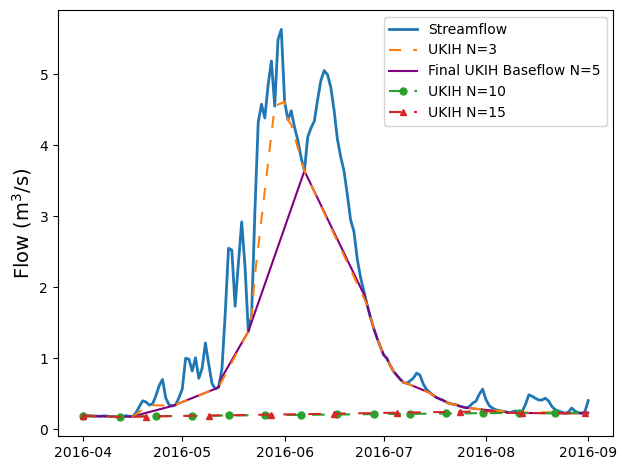

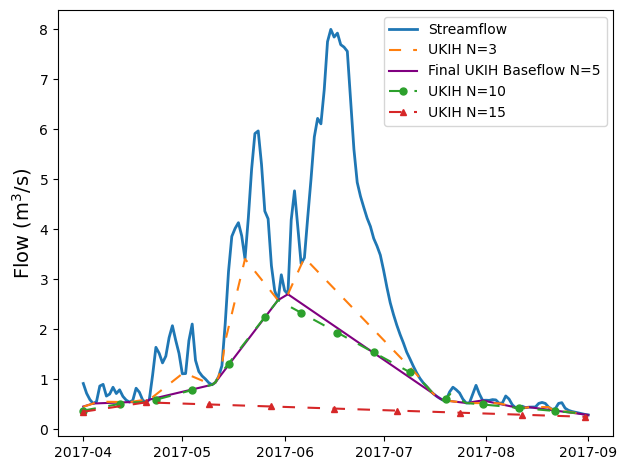

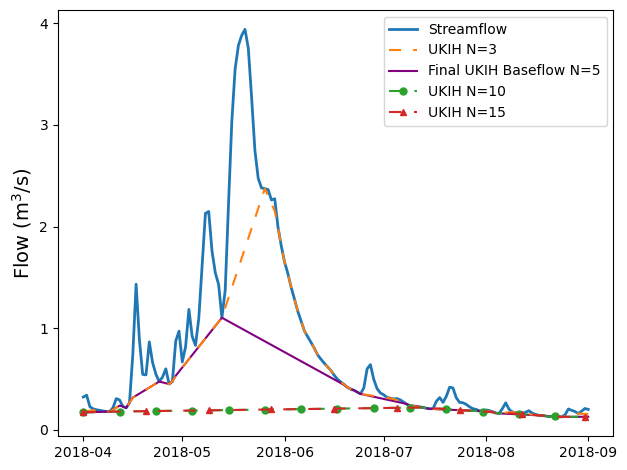

In [99]:
plot_ukih_zoom("2016-04-01", "2016-09-01", "figures/UKIH_sensitivity_zoom_2016.png")
plot_ukih_zoom("2017-04-01", "2017-09-01", "figures/UKIH_sensitivity_zoom_2017.png")
plot_ukih_zoom("2018-04-01", "2018-09-01", "figures/UKIH_sensitivity_zoom_2018.png")

In [100]:

start = "2015-10-01"
end = "2018-10-01"

# subset all datasets
sf = UKIH_streamflow.loc[start:end]
bf3 = bf_ukih_3.loc[start:end]
bf5 = bf_ukih.loc[start:end]
bf10 = bf_ukih_10.loc[start:end]
bf15 = bf_ukih_15.loc[start:end]


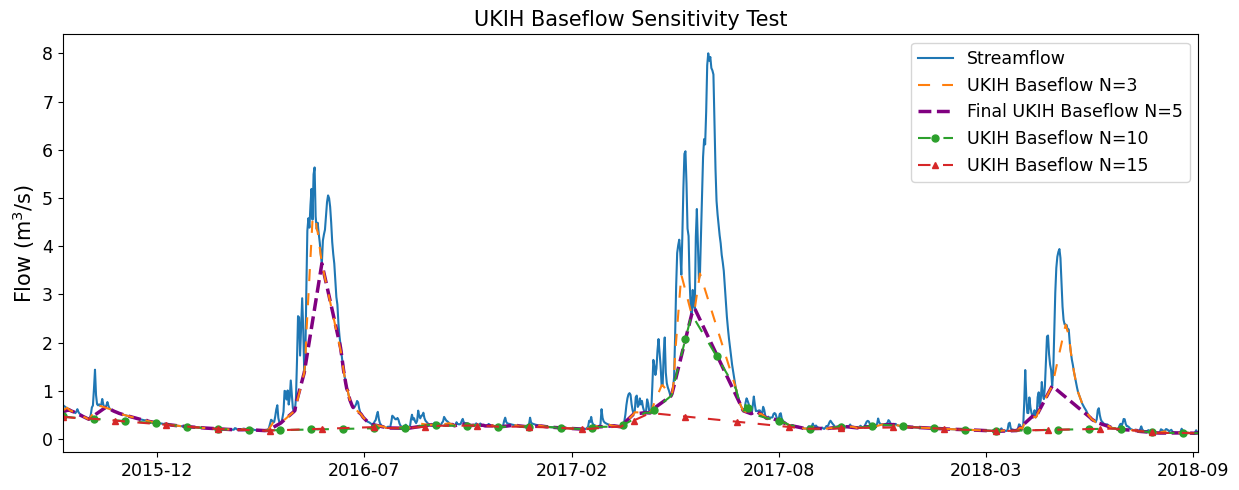

In [101]:

# --- plot ---
plt.figure(figsize=(12.5,5))

plt.plot(sf.index, sf[col], label="Streamflow", zorder=1)
plt.plot(bf3.index, bf3[col], label="UKIH Baseflow N=3", color="tab:orange", linestyle="--", dashes=(5.8,5.8))
plt.plot(bf5.index, bf5['watershed boundary discharge [m^3/s]'], label="Final UKIH Baseflow N=5", color="purple", linestyle="--", zorder=1, linewidth=2.5)
plt.plot(bf10.index, bf10[col], label="UKIH Baseflow N=10", color="tab:green", linestyle="--", marker="o", markevery=30, markersize=5, dashes=(6.1, 6.1))
plt.plot(bf15.index, bf15[col], label="UKIH Baseflow N=15", color="tab:red", linestyle="-.", dashes=(6,6), marker="^", markevery=50, markersize=5)

plt.ylabel(r"Flow (m$^3$/s)", fontsize=15)
plt.title("UKIH Baseflow Sensitivity Test", fontsize=15)

plt.xlim(pd.Timestamp('2015-10-01'), pd.Timestamp('2018-10-01'))

ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))





plt.tick_params(axis='x', labelsize=12.5)
plt.tick_params(axis='y', labelsize=12.5)





plt.legend(fontsize=12.5)

plt.tight_layout()
plt.savefig("figures/UKIH_sensitivity_2015_2018.png", dpi=500)
plt.show()




# (5) PH Graphical baseflow separation: 

#### Get the PH graphical method baseflows from the function used in the digital filter method, the "multi-method baseflow separation function"

In [102]:
combined_df = pd.DataFrame({
    'CMB': merged_df['MCB_baseflow_power_obsfit'],
    'Eckhardt_digital': b['Eckhardt'],
    'final_baseflow': df['final_baseflow [m3 s^-1]'],
    'streamflow': df['net runoff [m3 s^-1]'],
    'UKIH': bf_ukih['watershed boundary discharge [m^3/s]'],
    'Local_PH': b['Local'],
    'Fixed_PH': b['Fixed'],
    'Slide_PH': b['Slide'],
})

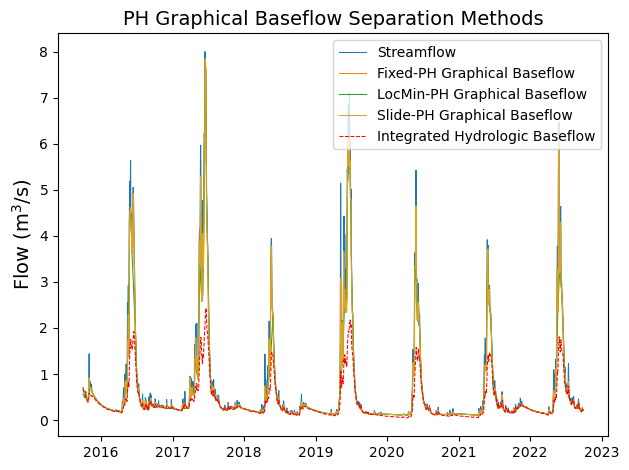

In [103]:
fig, ax = plt.subplots()



ax.plot(combined_df.index, combined_df['streamflow'], label='Streamflow', linewidth=0.75)

ax.plot(combined_df.index, combined_df['Fixed_PH'], label='Fixed-PH Graphical Baseflow', linewidth=0.75)
ax.plot(combined_df.index, combined_df['Local_PH'], label='LocMin-PH Graphical Baseflow', linewidth=0.75)
ax.plot(combined_df.index, combined_df['Slide_PH'], label='Slide-PH Graphical Baseflow', linewidth=0.75, color='#DAA520')
ax.plot(combined_df.index , combined_df['final_baseflow'], label='Integrated Hydrologic Baseflow', color='red', linestyle='--', linewidth=0.75)


ax.set_title('PH Graphical Baseflow Separation Methods', fontsize = fontsize)
ax.set_ylabel(r'Flow (m$^3$/s)', fontsize = fontsize)



ax.legend()
plt.tight_layout()
plt.savefig('figures/PH Graphical Method.png', dpi=500)
plt.show()

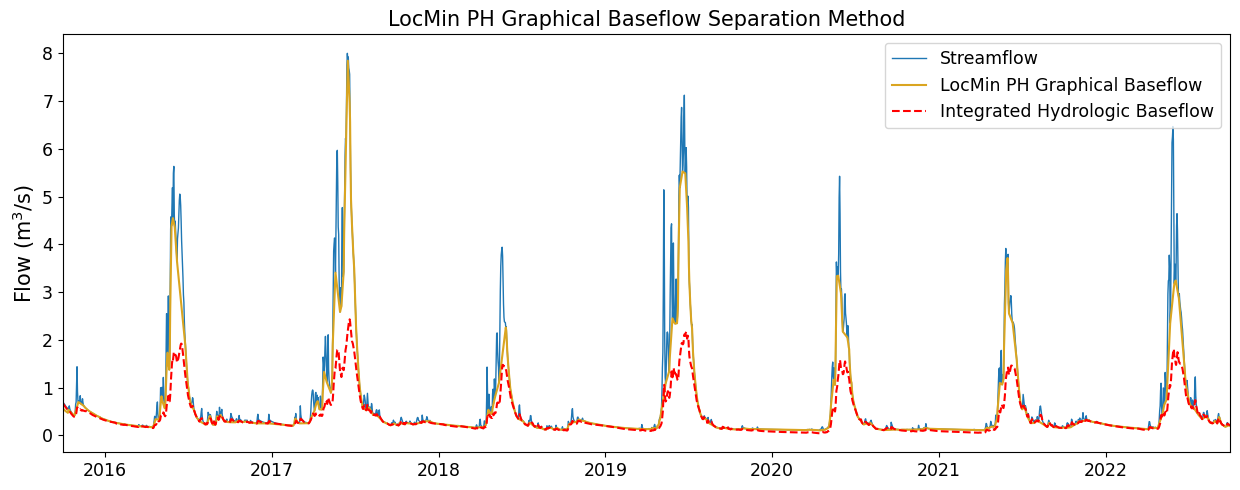

In [104]:
fig, ax = plt.subplots(figsize=(12.5, 5))


ax.plot(combined_df.index, combined_df['streamflow'], label='Streamflow', linewidth=1)
ax.plot(combined_df.index, combined_df['Local_PH'], label='LocMin PH Graphical Baseflow', color='#DAA520')

ax.plot(combined_df.index , combined_df['final_baseflow'], label='Integrated Hydrologic Baseflow', color='red', linestyle='--')


ax.set_xlim(pd.Timestamp('2015-10-01'), pd.Timestamp('2022-09-30'))

ax.set_title('LocMin PH Graphical Baseflow Separation Method', fontsize = 15)
ax.set_ylabel(r'Flow (m$^3$/s)', fontsize = 15)




ax.tick_params(axis='x', labelsize=12.5)
ax.tick_params(axis='y', labelsize=12.5)





plt.tight_layout()
ax.legend(fontsize=12.5)

plt.savefig('figures/locmin-PH Graphical Method.png', dpi=500)

plt.show()

#### Calculate the yearly BFI and its average BFI

In [105]:
methods = [
    'Slide_PH',
    'Fixed_PH',
    'Local_PH'
]

# Resample data by water year (ending in September) or calendar year ('A')
yearly_bfi = combined_df.resample('A-SEP').apply(
    lambda df: {method: (df[method].sum() / df['streamflow'].sum()) for method in methods}
)

# Convert dictionary columns to a DataFrame
yearly_bfi_df = pd.DataFrame(list(yearly_bfi)).set_index(combined_df.resample('A-SEP').sum().index.year)

# Calculate yearly average BFI across methods
yearly_bfi_df['Average_BFI'] = yearly_bfi_df.mean(axis=1)

print(yearly_bfi_df)


      Slide_PH  Fixed_PH  Local_PH  Average_BFI
2016  0.909823  0.902049  0.855028     0.888967
2017  0.903784  0.899213  0.874933     0.892644
2018  0.901235  0.908171  0.802911     0.870772
2019  0.886995  0.893461  0.851681     0.877379
2020  0.905922  0.901982  0.892087     0.899997
2021  0.915295  0.905843  0.904707     0.908615
2022  0.891115  0.878811  0.794907     0.854944


C:\Users\jihad\AppData\Local\Temp\ipykernel_36352\330822519.py:8: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  yearly_bfi = combined_df.resample('A-SEP').apply(
C:\Users\jihad\AppData\Local\Temp\ipykernel_36352\330822519.py:13: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  yearly_bfi_df = pd.DataFrame(list(yearly_bfi)).set_index(combined_df.resample('A-SEP').sum().index.year)


In [106]:
final_avg_bfis = yearly_bfi_df.mean()

print("Final Average BFI from Yearly Values:")
for method, avg in final_avg_bfis.items():
    print(f"{method}: {avg:.3f}")

Final Average BFI from Yearly Values:
Slide_PH: 0.902
Fixed_PH: 0.899
Local_PH: 0.854
Average_BFI: 0.885


#### Plot zoom in to year 2016

In [107]:
startdate = '2016-04-01'
enddate = '2016-09-01'
PH_combined_df = combined_df.loc[startdate:enddate]

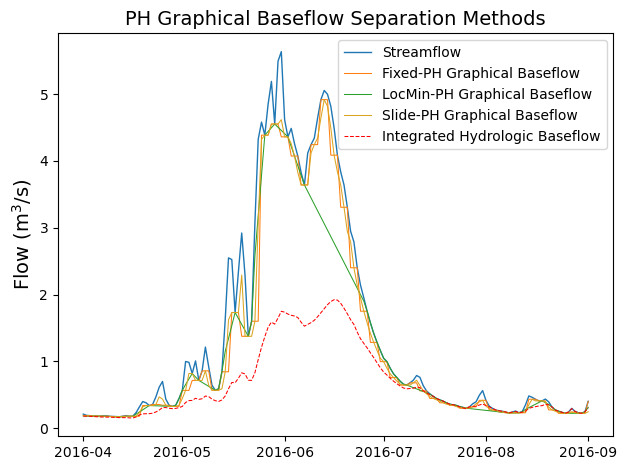

In [108]:
fig, ax = plt.subplots()


ax.plot(PH_combined_df.index, PH_combined_df['streamflow'], label='Streamflow', linewidth=1)

ax.plot(PH_combined_df.index, PH_combined_df['Fixed_PH'], label='Fixed-PH Graphical Baseflow', linewidth=0.75)
ax.plot(PH_combined_df.index, PH_combined_df['Local_PH'], label='LocMin-PH Graphical Baseflow', linewidth=0.75)
ax.plot(PH_combined_df.index, PH_combined_df['Slide_PH'], label='Slide-PH Graphical Baseflow', linewidth=0.75, color='#DAA520')
ax.plot(PH_combined_df.index , PH_combined_df['final_baseflow'], label='Integrated Hydrologic Baseflow', color='red', linestyle='--', linewidth=0.75)



# ax.set_title('PH Graphical Baseflow Separation Methods', fontsize = fontsize)
ax.set_ylabel(r'Flow (m$^3$/s)', fontsize = fontsize)
ax.set_title('PH Graphical Baseflow Separation Methods', fontsize = fontsize)


plt.tight_layout()
ax.legend()

plt.savefig('figures/PH Graphical Method_all_zoom.png', dpi=500)

plt.show()

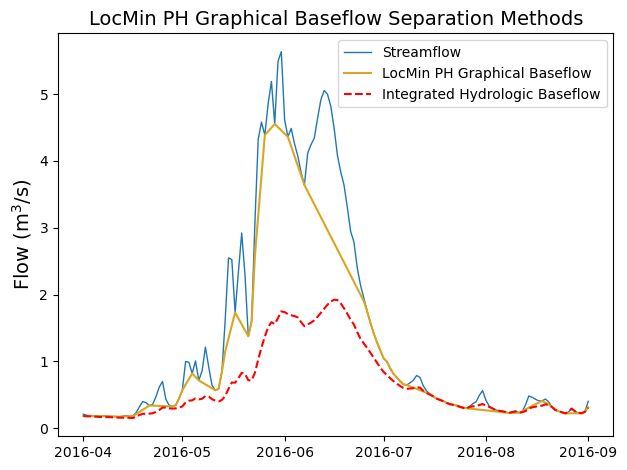

In [109]:
fig, ax = plt.subplots()


ax.plot(PH_combined_df.index, PH_combined_df['streamflow'], label='Streamflow', linewidth=1)

ax.plot(PH_combined_df.index, PH_combined_df['Local_PH'], label='LocMin PH Graphical Baseflow', color='#DAA520')
ax.plot(PH_combined_df.index , PH_combined_df['final_baseflow'], label='Integrated Hydrologic Baseflow', color='red', linestyle='--')



ax.set_ylabel(r'Flow (m$^3$/s)', fontsize = fontsize)
ax.set_title('LocMin PH Graphical Baseflow Separation Methods', fontsize = fontsize)


plt.tight_layout()
ax.legend()

plt.savefig('figures/PH Graphical Method_2016.png', dpi=500)

plt.show()

#### Plotting turning points:

In [110]:
# Extract LocMin baseflow series
locmin_series = PH_combined_df['Local_PH']
locmin_index = PH_combined_df.index

# Compute slope
slope = np.diff(locmin_series)

# Set threshold for significant slope change
threshold = 0.001  
slope_diff = np.diff(slope)
significant_change = np.abs(slope_diff) > threshold

# Indices of turning points
turning_idx = np.where(significant_change)[0] + 1  # +1 to correct for diff offset

# Get the corresponding dates and values
turning_dates = locmin_index[turning_idx]
turning_values = locmin_series.iloc[turning_idx]

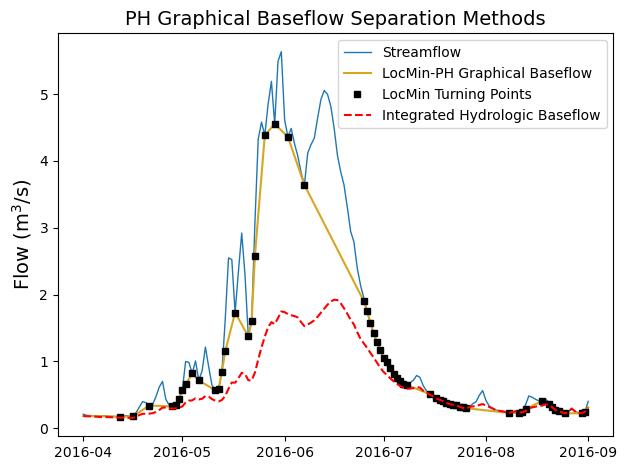

In [111]:
fig, ax = plt.subplots()

# Plot streamflow
ax.plot(PH_combined_df.index, PH_combined_df['streamflow'], label='Streamflow', linewidth=1)

# Plot LocMin baseflow line
ax.plot(PH_combined_df.index, PH_combined_df['Local_PH'], label='LocMin-PH Graphical Baseflow', color='#DAA520')

# Plot turning point markers
ax.plot(turning_dates, turning_values, 'ks', markersize=5, label='LocMin Turning Points')  # black squares

# Plot Integrated Hydrologic Baseflow
ax.plot(PH_combined_df.index, PH_combined_df['final_baseflow'], label='Integrated Hydrologic Baseflow', color='red', linestyle='--')

# Labels
ax.set_ylabel(r'Flow (m$^3$/s)', fontsize=fontsize)
ax.set_title('PH Graphical Baseflow Separation Methods', fontsize = fontsize)

plt.tight_layout()
ax.legend()

plt.savefig('figures/PH Graphical Method_turning_points.png', dpi=500)
plt.show()


## Sensitivity test for the N values in the PH graphical method

In [112]:
def clean_streamflow(series):
    if not isinstance(series, pd.Series):
        raise ValueError("Input must be a pandas Series")
    if not isinstance(series.index, pd.DatetimeIndex):
        raise ValueError("Series index must be a DateTimeIndex")

    date = series.index
    Q = series.values.astype(float)

    has_value = np.isfinite(Q)
    date = date[has_value]
    Q = np.abs(Q[has_value])

    # Water year: Oct–Sep belongs to the NEXT calendar year
    water_years = np.where(date.month >= 10, date.year + 1, date.year)

    # Keep water years with at least 120 daily values
    wy_unique, wy_counts = np.unique(water_years, return_counts=True)
    valid_wy = wy_unique[wy_counts >= 120]

    keep = np.isin(water_years, valid_wy)
    return Q[keep], date[keep]

In [113]:
def hysep_interval(area_km2, factor=1.0):
    if area_km2 is None:
        N = 5
    else:
        A_mi2 = 0.3861022 * area_km2
        N = factor * (A_mi2 ** 0.2)

    inN = np.ceil(2 * N)
    if inN % 2 == 0:
        inN = np.ceil(2 * N) - 1

    inN = int(min(max(inN, 3), 11))
    return inN

In [114]:
def Local_with_factor(Q, b_LH, area_km2, factor=1.0, return_exceed=False):
    interval = hysep_interval(area_km2, factor=factor)

    idx_turn = Local_turn(Q, interval)
    if idx_turn.shape[0] < 3:
        raise IndexError("Less than 3 turning points found")

    b = linear_interpolation(Q, idx_turn, return_exceed=return_exceed)
    b[idx_turn[0]] = b_LH[idx_turn[0]]
    b[idx_turn[-1] + 1:] = b_LH[idx_turn[-1] + 1:]
    return b


In [115]:
def single(series, area_km2, method="all", local_factor=1.0):
    Q, date = clean_streamflow(series)
    method = format_method(method)

    b_LH = LH(Q)
    b = pd.DataFrame(np.nan, index=date, columns=method)

    for m in method:
        if m == "UKIH":
            b[m] = UKIH(Q, b_LH)

        elif m == "Local":
            b[m] = Local_with_factor(Q, b_LH, area_km2, factor=local_factor)

        elif m == "Fixed":
            b[m] = Fixed(Q, area_km2)

        elif m == "Slide":
            b[m] = Slide(Q, area_km2)

        elif m == "LH":
            b[m] = b_LH

        elif m == "Eckhardt":
            b[m] = Eckhardt(Q, b_LH, recession_constant_a_gw, BFImax)

    return b

In [116]:
area_km2 = 53.2
series = xie_baseflow["watershed boundary discharge [m^3/s]"]

b_orig = single(series, area_km2, method="all", local_factor=1.0)
b_15  = single(series, area_km2, method="all", local_factor=1.5)
b_20  = single(series, area_km2, method="all", local_factor=2)
b_25  = single(series, area_km2, method="all", local_factor=2.5)

b_orig = b_orig[b_orig.index >= "2015-10-01"]
b_15  = b_15[b_15.index  >= "2015-10-01"]
b_20  = b_20[b_20.index  >= "2015-10-01"]
b_25  = b_25[b_25.index  >= "2015-10-01"]

# Optional: check the interval used
print("HYSEP interval (original):", hysep_interval(area_km2, factor=1.0))
print("HYSEP interval (factor 1.5):", hysep_interval(area_km2, factor=1.5))
print("HYSEP interval (factor 2):", hysep_interval(area_km2, factor=2))
print("HYSEP interval (factor 2.5):", hysep_interval(area_km2, factor=2.5))

HYSEP interval (original): 3
HYSEP interval (factor 1.5): 5
HYSEP interval (factor 2): 7
HYSEP interval (factor 2.5): 9


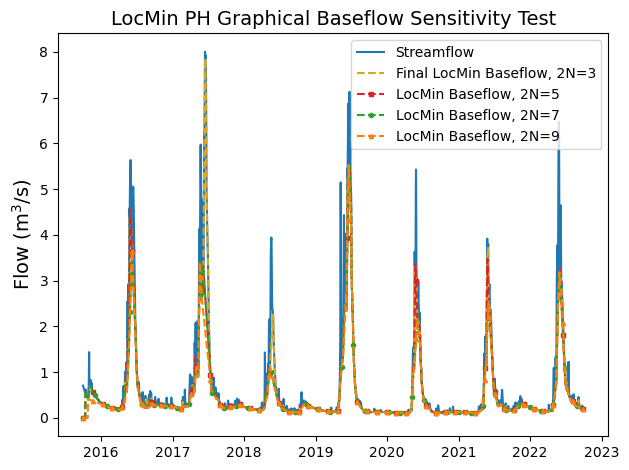

In [117]:
plt.figure()

# Streamflow
plt.plot(xie_baseflow.index, xie_baseflow['watershed boundary discharge [m^3/s]'], label='Streamflow')

# Local baseflow – original HYSEP (factor 1)
plt.plot(b_orig.index, b_orig['Local'], label='Final LocMin Baseflow, 2N=3', color='#DAA520', linestyle="--")

# Local baseflow – modified HYSEP (factor 1.5)
plt.plot(b_15.index, b_15['Local'], label='LocMin Baseflow, 2N=5', color="tab:red", marker="s", linestyle="--", markevery=50, markersize=3)

# Local baseflow – modified HYSEP (factor 2)
plt.plot(b_20.index, b_20['Local'], label='LocMin Baseflow, 2N=7', color="tab:green",linestyle="--",marker="o", markevery=60, markersize=3)

# Local baseflow – modified HYSEP (factor 2.5)
plt.plot(b_25.index, b_25['Local'], label='LocMin Baseflow, 2N=9', color="tab:orange", linestyle="--", marker="^", markevery=50, markersize=3)

# Optional: integrated model
# plt.plot(df.index, df['final_baseflow [m3 s^-1]'], label='Integrated Hydrologic Baseflow', color='red', linestyle='--')

plt.legend()
plt.title('LocMin PH Graphical Baseflow Sensitivity Test', fontsize=fontsize)
plt.ylabel(r'Flow (m$^3$/s)', fontsize=fontsize)

plt.tight_layout()
plt.savefig('figures/LocMin_sensitivity.png', dpi=500)
plt.show()


# ,marker="o", markevery=30, markersize=5    marker="^", markevery=50, markersize=5


In [118]:
def plot_zoom(startdate, enddate):

    plt.figure()

    # Streamflow
    plt.plot(
        xie_baseflow.loc[startdate:enddate].index,
        xie_baseflow.loc[startdate:enddate, 'watershed boundary discharge [m^3/s]'],
        label='Streamflow'
    )

    # Local factor 1
    plt.plot(
        b_orig.loc[startdate:enddate].index,
        b_orig.loc[startdate:enddate, 'Local'],
        label='Final LocMin Baseflow, 2N=3',
        color='#DAA520', linestyle="--"
    )

    # factor 1.5
    plt.plot(
        b_15.loc[startdate:enddate].index,
        b_15.loc[startdate:enddate, 'Local'],
        color="tab:red", label='LocMin Baseflow, 2N=5', linestyle="--", dashes=(6, 6), marker="s", markevery=11, markersize=5.5
    )

    # factor 2
    plt.plot(
        b_20.loc[startdate:enddate].index,
        b_20.loc[startdate:enddate, 'Local'],
        color="tab:green", label='LocMin Baseflow, 2N=7', linestyle="--",marker="o", markevery=13, markersize=5.5, dashes=(5, 5)
    )

    # factor 2.5
    plt.plot(
        b_25.loc[startdate:enddate].index,
        b_25.loc[startdate:enddate, 'Local'],
        color="tab:orange", label='LocMin Baseflow, 2N=9', linestyle="--", marker="^", markevery=15, markersize=5.5, dashes=(5,6)
    )
    
    plt.legend()
    # plt.title(f'LocMin PH Graphical Baseflow Sensitivity Test ({startdate} → {enddate})', fontsize=fontsize)
    plt.ylabel(r'Flow (m$^3$/s)', fontsize=fontsize)

    plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

    plt.tight_layout()
    plt.savefig(f'figures/LocMin_sens_zoom_{startdate}_{enddate}.png', dpi=500)
    plt.show()


# ,marker="o", markevery=30, markersize=5    marker="^", markevery=50, markersize=5

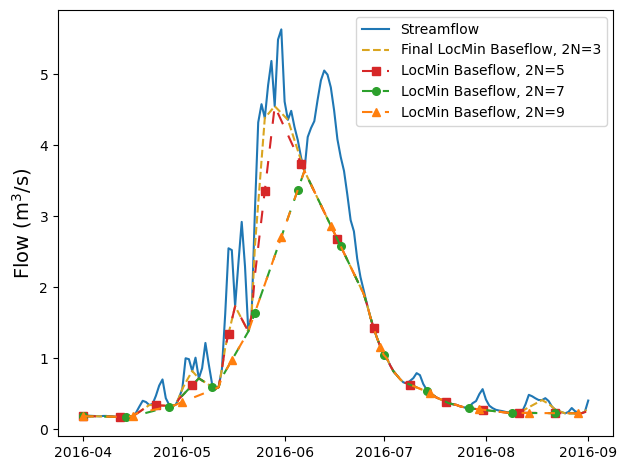

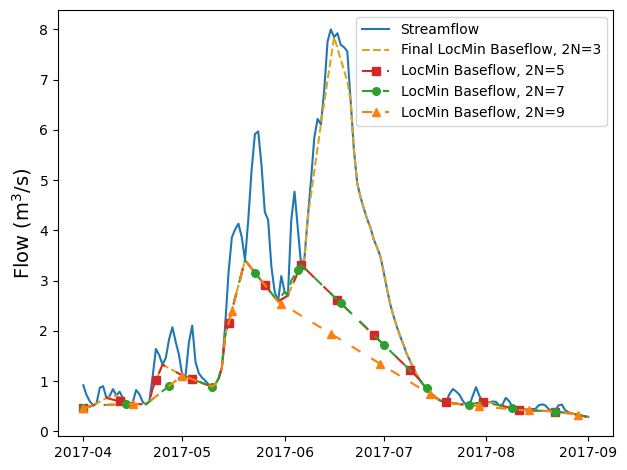

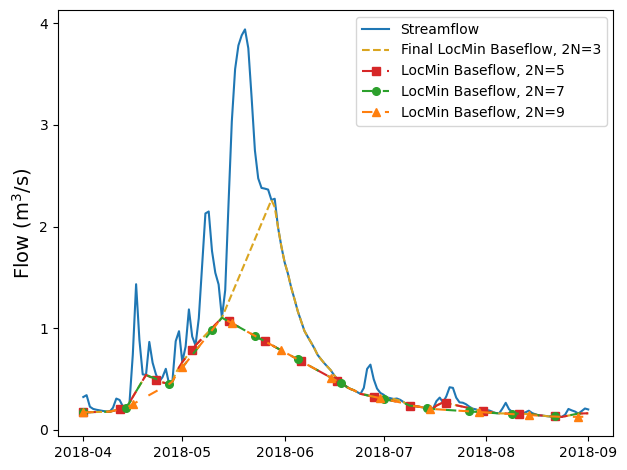

In [119]:
plot_zoom('2016-04-01', '2016-09-01')
plot_zoom('2017-04-01', '2017-09-01')
plot_zoom('2018-04-01', '2018-09-01')

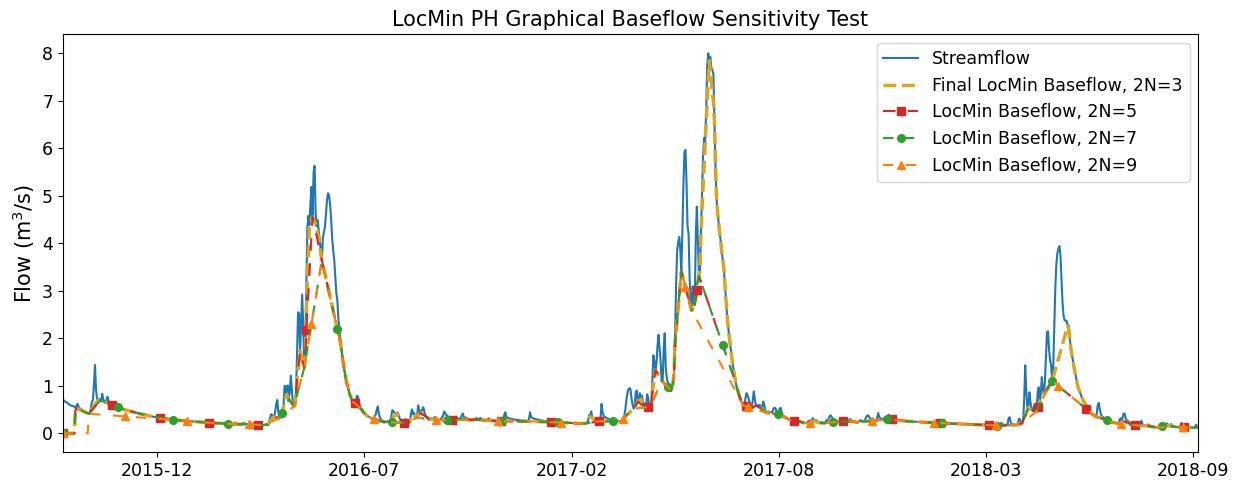

In [120]:
startdate = "2015-10-01"
enddate = "2018-10-01"

plt.figure(figsize=(12.5,5))

# Streamflow
plt.plot(
    xie_baseflow.loc[startdate:enddate].index,
    xie_baseflow.loc[startdate:enddate, 'watershed boundary discharge [m^3/s]'],
    label='Streamflow'
)

# Local factor 1
plt.plot(
    b_orig.loc[startdate:enddate].index,
    b_orig.loc[startdate:enddate, 'Local'],
    label='Final LocMin Baseflow, 2N=3',
    color='#DAA520',
    linestyle="--",  linewidth=2.5
)

# factor 1.5
plt.plot(
    b_15.loc[startdate:enddate].index,
    b_15.loc[startdate:enddate, 'Local'],
    color="tab:red",
    label='LocMin Baseflow, 2N=5',
    linestyle="--",
    dashes=(6,6),
    marker="s",
    markevery=47,
    markersize=5.5
)

# factor 2
plt.plot(
    b_20.loc[startdate:enddate].index,
    b_20.loc[startdate:enddate, 'Local'],
    color="tab:green",
    label='LocMin Baseflow, 2N=7',
    linestyle="--",
    marker="o",
    markevery=53,
    markersize=5.5,
    dashes=(5,5)
)

# factor 2.5
plt.plot(
    b_25.loc[startdate:enddate].index,
    b_25.loc[startdate:enddate, 'Local'],
    color="tab:orange",
    label='LocMin Baseflow, 2N=9',
    linestyle="--",
    marker="^",
    markevery=60,
    markersize=5.5,
    dashes=(5,6)
)

# Labels
plt.ylabel(r'Flow (m$^3$/s)', fontsize=15)
plt.legend(fontsize=12.5)

plt.title('LocMin PH Graphical Baseflow Sensitivity Test', fontsize=15)

# Integer y ticks
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
plt.xlim(pd.Timestamp('2015-10-01'), pd.Timestamp('2018-10-01'))
# Clean year x-axis
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))



ax.tick_params(axis='x', labelsize=12.5)
ax.tick_params(axis='y', labelsize=12.5)




plt.tight_layout()
plt.savefig('figures/LocMin_sens_zoom_2015_2018.png', dpi=500)
plt.show()

# plot all the baseflow from numerical model, UKIH, HYSEP graphical, digital, numerical, and mass balance method:

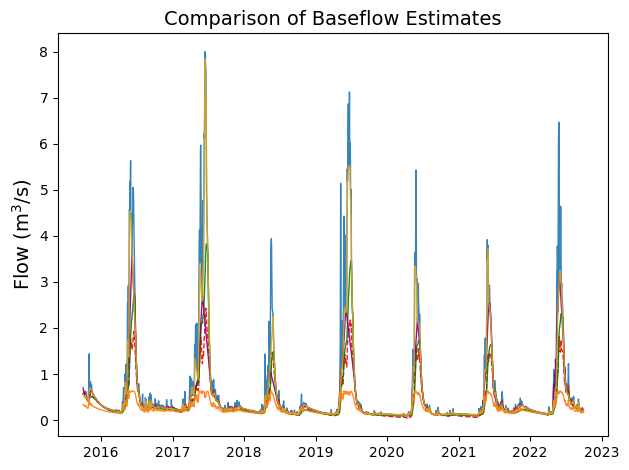

In [121]:
fig, ax = plt.subplots()


ax.plot(combined_df.index, combined_df['streamflow'], label='Streamflow', linewidth=1,alpha = 0.9)

ax.plot(combined_df.index, combined_df['final_baseflow'], label='Integrated Hydrologic Baseflow',color = 'red', linewidth=1,alpha = 0.9, linestyle='--')

ax.plot(combined_df.index, combined_df['Eckhardt_digital'], label='Eckhardt Digital Filter Baseflow', color='green', linewidth=1,alpha = 0.9)

ax.plot(combined_df.index, combined_df['UKIH'], label='UKIH Graphical Baseflow', color = 'purple', linewidth=1,alpha = 0.9)

ax.plot(combined_df.index, combined_df['CMB'], label='Conductance Mass Balance Baseflow', linewidth=1,alpha = 0.9)

ax.plot(combined_df.index, combined_df['Local_PH'], label='LocMin Graphical Baseflow', color='#DAA520', linewidth=1,alpha = 0.9)


# Set the plot title and labels
ax.set_title('Comparison of Baseflow Estimates', fontsize = fontsize)
ax.set_ylabel(r'Flow (m$^3$/s)', fontsize = fontsize)




plt.tight_layout()
plt.savefig('figures/Comparison_of_Baseflow_separation_final.png', dpi=500)

plt.show()

In [122]:
startdate = '2016-04-01'
enddate = '2016-09-01'
filtered_combined_df = combined_df.loc[startdate:enddate]

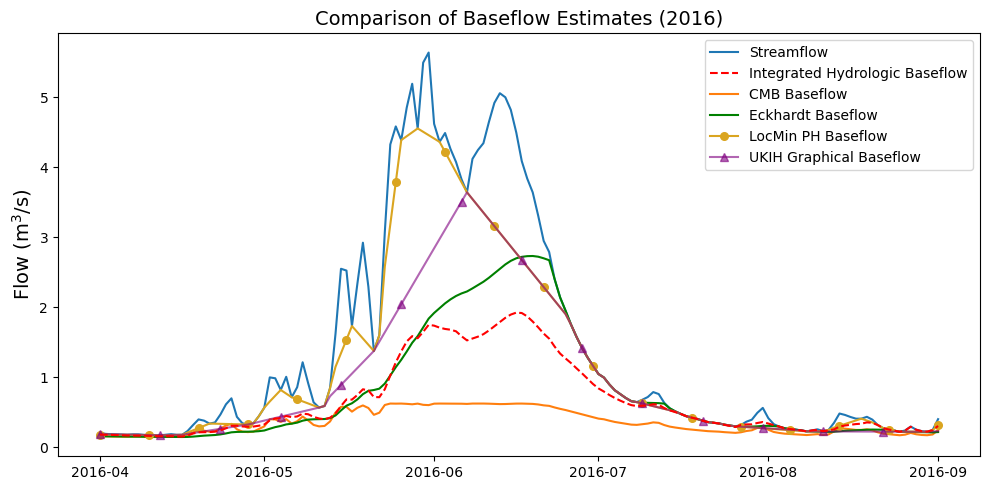

In [123]:
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(filtered_combined_df.index, filtered_combined_df['streamflow'], label='Streamflow')


# Plot simulated baseflow
ax.plot(filtered_combined_df.index, filtered_combined_df['final_baseflow'], label='Integrated Hydrologic Baseflow', color='red', linestyle='--', zorder=10)
ax.plot(filtered_combined_df.index, filtered_combined_df['CMB'], label='CMB Baseflow')
ax.plot(filtered_combined_df.index, filtered_combined_df['Eckhardt_digital'], label='Eckhardt Baseflow', color='green')
ax.plot(filtered_combined_df.index, filtered_combined_df['Local_PH'], label='LocMin PH Baseflow', color='#DAA520', marker="o", markevery=9, markersize=5.5)
ax.plot(filtered_combined_df.index, filtered_combined_df['UKIH'], label='UKIH Graphical Baseflow', color = 'purple', alpha=0.6, marker="^", markevery=11, markersize=5.5)

# Set the plot title and labels
ax.set_title('Comparison of Baseflow Estimates (2016)', fontsize = fontsize)
ax.set_ylabel(r'Flow (m$^3$/s)', fontsize = fontsize)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))  # show every 2nd month
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # format as YYYY-MM
ax.legend()
# plt.gcf().autofmt_xdate(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('figures/Comparison_of_Baseflow_Estimates_final_wet_2016.png', dpi=500)

plt.show()


# linestyle="--",
# marker="^",
# markevery=40,
# markersize=5.5,
# dashes=(5,6)




In [124]:
startdate = '2017-02-01'
enddate = '2017-09-01'
filtered_combined_df = combined_df.loc[startdate:enddate]

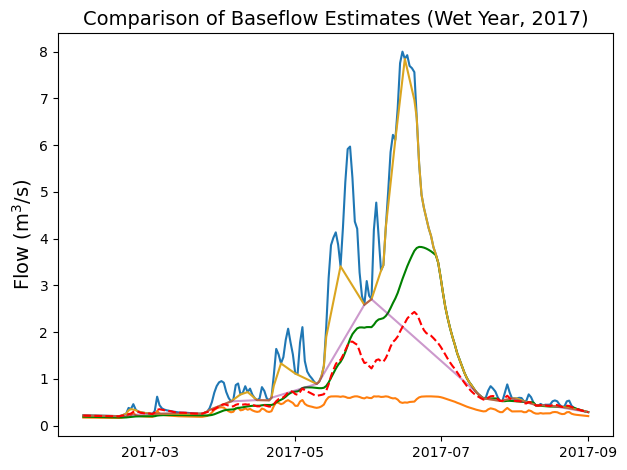

In [125]:
fig, ax = plt.subplots()

ax.plot(filtered_combined_df.index, filtered_combined_df['streamflow'], label='Streamflow')


# Plot simulated baseflow
ax.plot(filtered_combined_df.index, filtered_combined_df['final_baseflow'], label='Integrated Hydrologic Baseflow', color='red', linestyle='--', zorder=10)
ax.plot(filtered_combined_df.index, filtered_combined_df['CMB'], label='Conductance Mass Balance Baseflow')
ax.plot(filtered_combined_df.index, filtered_combined_df['Eckhardt_digital'], label='Eckhardt Digital Filter Baseflow', color='green')
ax.plot(filtered_combined_df.index, filtered_combined_df['Local_PH'], label='LocMin-Pettyjohn Graphical Baseflow', color='#DAA520')
ax.plot(filtered_combined_df.index, filtered_combined_df['UKIH'], label='UKIH Graphical Baseflow', color = 'purple', alpha=0.4)

# Set the plot title and labels
ax.set_title('Comparison of Baseflow Estimates (Wet Year, 2017)', fontsize = fontsize)
ax.set_ylabel(r'Flow (m$^3$/s)', fontsize = fontsize)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))  # show every 2nd month
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # format as YYYY-MM

# plt.gcf().autofmt_xdate(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('figures/Comparison_of_Baseflow_Estimates_final_wet_2017.png', dpi=500)

plt.show()

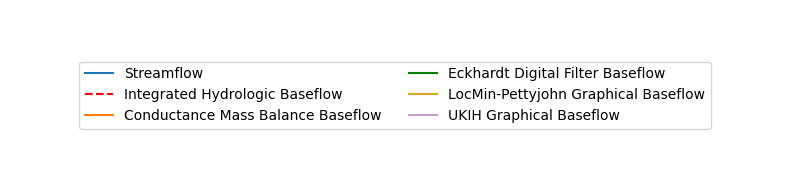

In [126]:
fig_legend = plt.figure(figsize=(8, 2))
ax_legend = fig_legend.add_subplot(111)
fig_legend.legend(*ax.get_legend_handles_labels(), loc='center', ncol=2)
ax_legend.axis('off')
plt.tight_layout()
fig_legend.savefig('figures/Comparison_of_Baseflow_Legend.png', dpi=500, bbox_inches='tight')

plt.show()

In [127]:
startdate = '2021-02-01'
enddate = '2021-09-01'
filtered_combined_df = combined_df.loc[startdate:enddate]

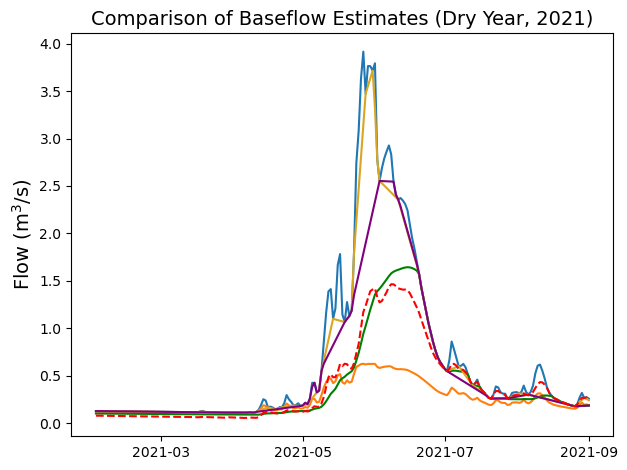

In [128]:
fig, ax = plt.subplots()

ax.plot(filtered_combined_df.index, filtered_combined_df['streamflow'], label='Streamflow')



# Plot simulated baseflow
ax.plot(filtered_combined_df.index, filtered_combined_df['final_baseflow'], label='Integrated Hydrologic Baseflow', color='red', linestyle='--', zorder=10)
ax.plot(filtered_combined_df.index, filtered_combined_df['CMB'], label='Conductance Mass Balance Baseflow')
ax.plot(filtered_combined_df.index, filtered_combined_df['Eckhardt_digital'], label='Eckhardt Digital Filter Baseflow', color='green')
ax.plot(filtered_combined_df.index, filtered_combined_df['Local_PH'], label='LocMin-Pettyjohn Graphical Baseflow', color='#DAA520')
ax.plot(filtered_combined_df.index, filtered_combined_df['UKIH'], label='UKIH Graphical Baseflow', color = 'purple')

# Set the plot title and labels
ax.set_title('Comparison of Baseflow Estimates (Dry Year, 2021)', fontsize = fontsize)
ax.set_ylabel(r'Flow (m$^3$/s)', fontsize = fontsize)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))  # show every 2nd month
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # format as YYYY-MM

plt.tight_layout()
plt.savefig('figures/Comparison_of_Baseflow_Estimates_final_zoom_dry_2021.png', dpi=500)

plt.show()

In [129]:
startdate = '2022-02-01'
enddate = '2022-09-01'
filtered_combined_df = combined_df.loc[startdate:enddate]

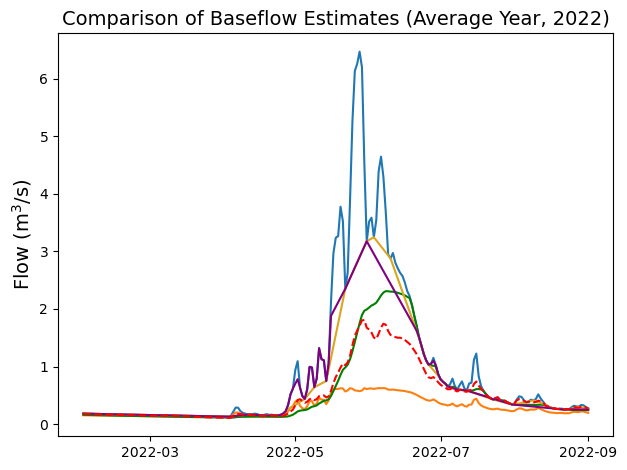

In [130]:
fig, ax = plt.subplots()

ax.plot(filtered_combined_df.index, filtered_combined_df['streamflow'], label='Streamflow')


ax.plot(filtered_combined_df.index, filtered_combined_df['final_baseflow'], label='Integrated Hydrologic Baseflow', color='red', linestyle='--', zorder=10)
ax.plot(filtered_combined_df.index, filtered_combined_df['CMB'], label='Conductance Mass Balance Baseflow')
ax.plot(filtered_combined_df.index, filtered_combined_df['Eckhardt_digital'], label='Eckhardt Digital Filter Baseflow', color='green')
ax.plot(filtered_combined_df.index, filtered_combined_df['Local_PH'], label='LocMin-Pettyjohn Graphical Baseflow', color='#DAA520')
ax.plot(filtered_combined_df.index, filtered_combined_df['UKIH'], label='UKIH Graphical Baseflow', color = 'purple')

# Set the plot title and labels
ax.set_title('Comparison of Baseflow Estimates (Average Year, 2022)', fontsize = fontsize)
ax.set_ylabel(r'Flow (m$^3$/s)', fontsize = fontsize)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))  # show every 2nd month
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # format as YYYY-MM

plt.tight_layout()
plt.savefig('figures/Comparison_of_Baseflow_Estimates_final_zoom_avg_2022.png', dpi=500)

plt.show()

### Save combined_df dataframe

In [131]:
combined_df.to_csv('combined_df.csv', index=True)

## Calculate the yearly BFI and its average for each method, , in addition to the NSE and  mKGE of UKIH and Eckhardt baseflow

#### Calculate the yearly BFI and its average

In [132]:
methods = ['final_baseflow', 
           'Eckhardt_digital', 
           'UKIH', 
           'CMB', 
           'Local_PH']

yearly_bfi_df = pd.DataFrame()

for method in methods:
    bf = combined_df[method]
    sf = combined_df['streamflow']
    
    valid_mask = bf.notna()
    bf_valid = bf[valid_mask]
    sf_valid = sf[valid_mask]

    bf_yearly = bf_valid.resample('A-SEP').sum()
    sf_yearly = sf_valid.resample('A-SEP').sum()

    bfi_yearly = (bf_yearly / sf_yearly) * 100
    yearly_bfi_df[method] = bfi_yearly

# convert datetime index to just the year
yearly_bfi_df.index = pd.to_datetime(yearly_bfi_df.index, errors='coerce').year.astype(str)

# Add mean and std rows
yearly_bfi_df.loc['Mean (%)'] = yearly_bfi_df.mean()
yearly_bfi_df.loc['Std (%)'] = yearly_bfi_df.std()

yearly_bfi_df


C:\Users\jihad\AppData\Local\Temp\ipykernel_36352\3141280022.py:17: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  bf_yearly = bf_valid.resample('A-SEP').sum()
C:\Users\jihad\AppData\Local\Temp\ipykernel_36352\3141280022.py:18: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  sf_yearly = sf_valid.resample('A-SEP').sum()
C:\Users\jihad\AppData\Local\Temp\ipykernel_36352\3141280022.py:17: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  bf_yearly = bf_valid.resample('A-SEP').sum()
C:\Users\jihad\AppData\Local\Temp\ipykernel_36352\3141280022.py:18: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  sf_yearly = sf_valid.resample('A-SEP').sum()
C:\Users\jihad\AppData\Local\Temp\ipykernel_36352\3141280022.py:17: FutureWarning: 'A-SEP' is deprecated and wil

,final_baseflow,Eckhardt_digital,UKIH,CMB,Local_PH
2016,59.323439,63.913978,74.652774,35.297723,85.502844
2017,51.694184,61.861110,56.546960,28.130273,87.493338
2018,69.449777,64.580180,66.314434,49.337311,80.291136
2019,49.510651,59.414844,56.156587,28.634256,85.168131
2020,56.679591,60.686655,74.198348,42.967123,89.208662
2021,59.852234,61.194122,81.964858,44.811271,90.470680
2022,60.685674,62.339625,79.442821,37.884903,79.490683
Mean (%),58.170793,61.998645,69.896683,38.151837,85.375068
Std (%),6.057630,1.669586,9.693386,7.482200,3.885509


#### Plot the yearly BFI histogram of the numerical method baseflow BFI

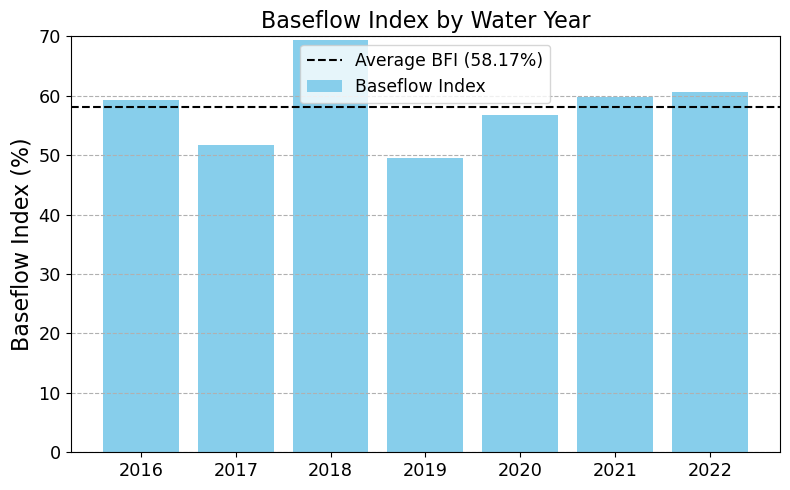

In [133]:
# Drop the summary rows and extract data
plot_df = yearly_bfi_df.drop(index=['Mean (%)', 'Std (%)'], errors='ignore')

# Convert index to integer years (if needed)
years = plot_df.index.astype(int)

# Extract final_baseflow BFI values
baseflow_index = plot_df['final_baseflow'].values

# Compute average
avg_baseflow = np.mean(baseflow_index)

# Plot
plt.figure(figsize=(8, 5))
plt.bar(years, baseflow_index, color='skyblue', label='Baseflow Index')

# Add average line
plt.axhline(y=avg_baseflow, color='black', linestyle='--', label=f'Average BFI ({avg_baseflow:.2f}%)')

# Labels and title
plt.ylabel('Baseflow Index (%)', fontsize=16)
plt.title('Baseflow Index by Water Year', fontsize=16)
plt.ylim(0, 70)
plt.legend(fontsize=12.4)
plt.tick_params(axis='both', labelsize=12.7)
plt.grid(axis='y', linestyle='--')
# plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save figure
plt.savefig('figures/baseflow_index_histogram.png', dpi=500)

# Show plot
plt.show()


In [134]:
def nse(obs, sim):
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)
    return 1 - np.sum((obs - sim) ** 2) / np.sum((obs - np.mean(obs)) ** 2)

In [135]:
try:
    from modvis.objectivefunctions import mkge as _mkge_pkg

    def mkge(sim, obs):
        # Note: modvis signature is (evaluation, simulation)
        return _mkge_pkg(np.asarray(obs, dtype=float), np.asarray(sim, dtype=float))

except ImportError:
    def mkge(sim, obs):
        sim = np.asarray(sim, dtype=float)
        obs = np.asarray(obs, dtype=float)

        r = np.corrcoef(sim, obs)[0, 1]


        cv_sim = np.std(sim) / (np.mean(sim))
        cv_obs = np.std(obs) / (np.mean(obs))
        alpha = cv_sim / (cv_obs)
        beta = (np.mean(sim)) / (np.mean(obs))
        
        return 1 - np.sqrt((r - 1) ** 2 + (alpha - 1) ** 2 + (beta - 1) ** 2)

In [136]:
years_to_analyze = ['2016', '2017', '2018', '2019', '2020', '2021', '2022']  # adjust if needed
results = []

In [137]:
for year in years_to_analyze:
    # Water year: Oct 1 (prev year) -> Sep 30 (this year)
    start_date = f"{int(year)-1}-10-01"
    end_date   = f"{year}-09-30"

    # Extract & align series
    model    = combined_df['final_baseflow'].loc[start_date:end_date]
    eckhardt = combined_df['Eckhardt_digital'].loc[start_date:end_date]
    ukih     = combined_df['UKIH'].loc[start_date:end_date]

    # Pairwise complete cases
    df = pd.concat([model, eckhardt, ukih], axis=1).dropna()
    if df.empty:
        results.append({
            'Water Year': year,
            'NSE_Eckhardt': np.nan,
            'NSE_UKIH': np.nan,
            'mKGE_Eckhardt': np.nan,
            'mKGE_UKIH': np.nan
        })
        continue

    model, eckhardt, ukih = df.iloc[:, 0], df.iloc[:, 1], df.iloc[:, 2]

    # Metrics (model is the "observation/target")
    nse_eck     = nse(model, eckhardt)
    nse_ukih    = nse(model, ukih)
    mkge_eck    = mkge(eckhardt, model)
    mkge_ukih   = mkge(ukih, model)

    results.append({
        'Water Year'      : year,
        'NSE_Eckhardt'    : round(nse_eck, 3),
        'NSE_UKIH'        : round(nse_ukih, 3),
        'mKGE_Eckhardt'   : round(mkge_eck, 3),
        'mKGE_UKIH'       : round(mkge_ukih, 3),
    })

In [138]:
nse_mkge_df = pd.DataFrame(results)
display(nse_mkge_df)

,Water Year,NSE_Eckhardt,NSE_UKIH,mKGE_Eckhardt,mKGE_UKIH
0,2016,0.725,0.118,0.654,0.484
1,2017,0.386,0.748,0.542,0.841
2,2018,0.947,0.777,0.837,0.800
3,2019,0.612,0.777,0.653,0.842
4,2020,0.923,0.782,0.906,0.689
5,2021,0.951,0.423,0.933,0.586
6,2022,0.791,0.103,0.665,0.510


mKGE: 0.4116143759957952, cc:  0.9296141291589213, alpha:  0.5477074807797648, beta:  0.6303042483633688


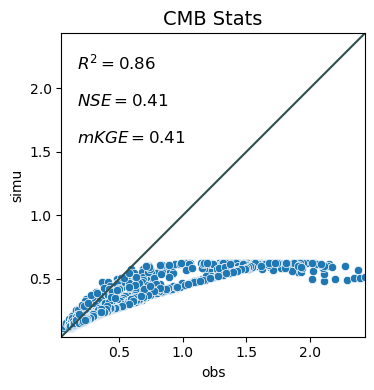

In [139]:
# One-to-one plots 
valid_data = combined_df.dropna(subset=['final_baseflow'])

gp.one2one_plot(
    valid_data['final_baseflow'],
    valid_data['CMB'],
    metrics=['R^2', 'NSE', 'mKGE'],
    show_density=False,
    start_date="2015-10-01",
    decompose_KGE=True
)
plt.title('CMB Stats', fontsize=14)
plt.tight_layout()

mKGE: 0.6755915629676941, cc:  0.9647527474116963, alpha:  1.3093791491199542, beta:  1.0910110284115782


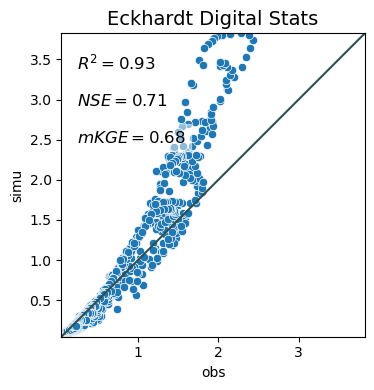

In [140]:
gp.one2one_plot(
    valid_data['final_baseflow'],
    valid_data['Eckhardt_digital'],
    metrics=['R^2', 'NSE', 'mKGE'],
    show_density=False,
    start_date="2015-10-01",
    decompose_KGE=True
)
plt.title('Eckhardt Digital Stats', fontsize=14)
plt.tight_layout()

mKGE: 0.7269671558477855, cc:  0.9214742817833407, alpha:  1.176586832507315, beta:  1.1928671463713785


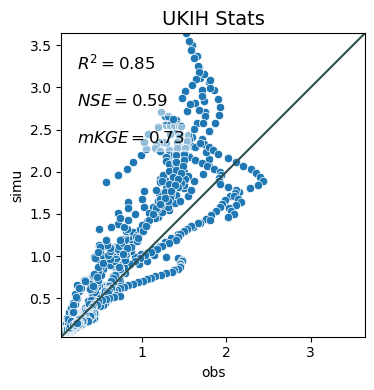

In [141]:
# valid_data = combined_df.dropna(subset=['final_baseflow'])
gp.one2one_plot(
    valid_data['final_baseflow'],
    valid_data['UKIH'],
    metrics=['R^2', 'NSE', 'mKGE'],
    show_density=False,
    start_date="2015-10-01",
    decompose_KGE=True
)
plt.title('UKIH Stats', fontsize=14)
plt.tight_layout()

mKGE: 0.2660092324243718, cc:  0.9358655484257732, alpha:  1.528833756114726, beta:  1.5049396769923349


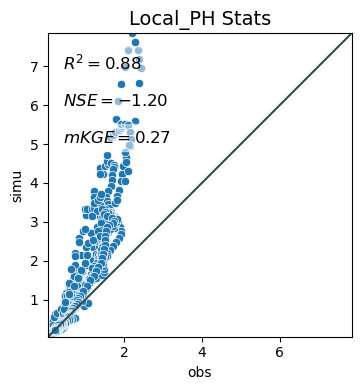

In [142]:
# valid_data = combined_df.dropna(subset=['final_baseflow'])
gp.one2one_plot(
    valid_data['final_baseflow'],
    valid_data['Local_PH'],
    metrics=['R^2', 'NSE', 'mKGE'],
    show_density=False,
    start_date="2015-10-01",
    decompose_KGE=True
)
plt.title('Local_PH Stats', fontsize=14)
plt.tight_layout()

### Classifying water years into average, dry, and wet years:

#### Classify water years into average, dry, and wet years based on ±0.5 standard deviation from mean annual discharge

In [143]:
# Resample to annual totals (water year: Oct–Sep if needed)
annual_discharge = combined_df['streamflow'].resample('A-SEP').sum()  # Water year ends in Sep

# Calculate mean and std
mean_val = annual_discharge.mean()
std_val = annual_discharge.std()

# Define thresholds
upper = mean_val + 0.5 * std_val
lower = mean_val - 0.5 * std_val

C:\Users\jihad\AppData\Local\Temp\ipykernel_36352\1978772538.py:2: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  annual_discharge = combined_df['streamflow'].resample('A-SEP').sum()  # Water year ends in Sep


In [144]:
# Classification function
def classify(val):
    if val > upper:
        return 'Wet'
    elif val < lower:
        return 'Dry'
    else:
        return 'Average'

# Apply classification
classification = annual_discharge.apply(classify)

# Combine results into one dataframe
classified_years = pd.DataFrame({
    'Annual_Discharge': annual_discharge,
    'Classification': classification
})

classified_years.index = classified_years.index.year.astype(str)
classified_years

,Annual_Discharge,Classification
2016,295.819069,Wet
2017,388.671534,Wet
2018,164.440177,Dry
2019,322.370380,Wet
2020,162.743531,Dry
2021,165.504634,Dry
2022,237.019829,Average
